<div style="text-align: center;">

# **Spring 2026 &mdash; CIS 3813<br>Advanced Data Science<br>(Introduction to Machine Learning)**
### Week 6: Logistic Regression & The Sigmoid Function

</div>

**Date:** 02 March 2026
**Time:** 6:00–9:00 PM  
**Instructor:** Dr. Patrick T. Marsh  
**Course Verse:** "He has shown you, O mortal, what is good. And what does the Lord require of you? To act justly and to love mercy and to walk humbly with your God."  &mdash; *Micah 6:8 (NIV)*

---

## **Week 6 Learning Objectives**

By the end of this lecture, you will be able to:

1. **Explain** the fundamental difference between regression and classification problems
2. **Understand** the sigmoid function and its mathematical properties
3. **Implement** logistic regression using scikit-learn
4. **Interpret** probability outputs from logistic regression models
5. **Convert** probabilities to class predictions using decision thresholds
6. **Apply** logistic regression to real-world binary classification problems
7. **Understand** the concept of log-loss as a loss function for classification

---

## **Today's Outline**
- Lecture  
- Break (10-15 Minutes)
- Lab (or Homework)
- Review
    1. Review & Wrap-Up
    2. Coming Up

---

## **Opening Reflection**

> *"The path of the righteous is like the morning sun,*  
> *shining ever brighter till the full light of day.*  
> *But the way of the wicked is like deep darkness;*  
> *they do not know what makes them stumble."*  
>
> **Proverbs 4:18-19 (NIV)**

In data science, we often work with classification problems that divide outcomes into distinct categories—much like the biblical distinction between light and darkness, right and wrong. Today we'll learn about logistic regression, a powerful algorithm that helps us predict which category an observation belongs to. Just as wisdom helps us discern between different paths in life, logistic regression helps us classify data points with precision and understanding.


---

## **1.1 Review of Last Week:** 

Last week, we explored crucial techniques for building robust machine learning models:

### **1.1.1 Cross-Validation**
Instead of a single train/test split, we used k-fold cross-validation to get a more reliable estimate of model performance
   - Splits data into k folds
   - Trains on k-1 folds, validates on 1 fold
   - Repeats k times, averaging results

### **1.1.2 Hyperparameter Tuning**
We learned to optimize model parameters that aren't learned from data:
   - `GridSearchCV`: Exhaustive search over specified parameter values
   - `RandomizedSearchCV`: Random sampling from parameter distributions
   
### **1.1.3 Pipeline Integration**
We combined preprocessing and modeling steps into clean, reproducible workflows

#### **Why This Matters for Today**

The cross-validation and hyperparameter tuning skills you learned last week are **essential** for today's topic. Logistic regression has its own hyperparameters (like regularization strength) that need tuning, and cross-validation helps us evaluate classification models reliably.

---

## **1.2 Introduction: From Regression to Classification**

### **1.2.1 Understanding the Fundamental Difference**

Up until now in this course, we've focused exclusively on **regression** problems. Let's review:

#### **What is Regression?**

**Definition:** Predicting a **continuous numeric value**

**Key Characteristics:**
- Output is a number on a continuous scale
- Can be any value within a range
- Often has units (dollars, degrees, meters, etc.)

**Examples:**
- **House Price Prediction:**
  - Input: Square footage, number of bedrooms, location
  - Output: Price ($150,000, $275,500, $425,750)
  - Range: $0 to millions
  - Infinitely many possible values

- **Temperature Forecasting:**
  - Input: Date, location, weather patterns
  - Output: Temperature (72°F, 85.3°F, 91.7°F)
  - Range: -50°F to 150°F
  - Continuous scale

- **Stock Price Prediction:**
  - Input: Historical prices, volume, market indicators
  - Output: Price ($45.23, $47.89, $44.12)
  - Range: $0 to thousands
  - Many decimal places possible

#### **What is Classification?**

**Definition:** Predicting which **category** (class) something belongs to

**Key Characteristics:**
- Output is a **discrete category**
- Finite number of possible outputs
- Often represented as labels or integers
- No inherent ordering (usually)

**Types of Classification:**

1. **Binary Classification** (2 classes) - **Today's focus!**
   - Yes/No
   - True/False
   - Positive/Negative
   - Class 0/Class 1

2. **Multi-class Classification** (3+ classes) - **Future topic**
   - Type A/Type B/Type C
   - Category 1/2/3/4/5
   - Multiple distinct groups

### **1.2.2 Real-World Classification Problems**

Let's explore concrete examples where classification is used:

#### **1.2.2.1. Healthcare & Medicine**

**Disease Diagnosis:**
- **Input:** Patient symptoms, test results, medical history, vitals
- **Output:** Diseased (1) or Healthy (0)
- **Examples:**
  - Does this patient have diabetes?
  - Is this tumor benign or malignant?
  - Will this patient have a heart attack in the next year?
  - Is this patient at risk for readmission within 30 days?

**Why it matters:**
- Early intervention can save lives
- Resource allocation (who needs more intensive care?)
- Preventive medicine

**Ethical considerations:**
- False negatives (missing sick patients) can be fatal
- False positives cause unnecessary stress and treatment
- Must be fair across demographic groups

#### **1.2.2.2. Business & Finance**

**Customer Churn Prediction:**
- **Input:** Usage patterns, payment history, customer service interactions, demographics
- **Output:** Will Churn (1) or Will Stay (0)
- **Business value:**
  - Acquiring new customer costs 5-25x more than retaining existing
  - Can proactively offer discounts/improvements to at-risk customers
  - Prioritize retention efforts

**Loan Default Prediction:**
- **Input:** Credit score, income, employment history, debt-to-income ratio
- **Output:** Will Default (1) or Will Repay (0)
- **Business value:**
  - Reduce financial risk
  - Set appropriate interest rates
  - Approve/deny loan applications

**Purchase Prediction:**
- **Input:** Browsing history, past purchases, demographics, time on site
- **Output:** Will Buy (1) or Won't Buy (0)
- **Business value:**
  - Targeted marketing
  - Personalized recommendations
  - Inventory management

#### **1.2.2.3. Technology & Security**

**Spam Email Detection:**
- **Input:** Email content, sender information, links, attachments
- **Output:** Spam (1) or Not Spam (0)
- **Challenge:** Balance between blocking spam and not blocking important emails

**Fraud Detection:**
- **Input:** Transaction amount, location, time, merchant, user behavior
- **Output:** Fraudulent (1) or Legitimate (0)
- **Challenge:** Fraud is rare (class imbalance), but very costly

**Click Prediction (Ad Tech):**
- **Input:** User profile, ad content, context, time of day
- **Output:** Will Click (1) or Won't Click (0)
- **Business value:** Billions of dollars in advertising revenue

#### **1.2.2.4. Education**

**Student Success Prediction:**
- **Input:** GPA, attendance, engagement, demographics, prior performance
- **Outputs:**
  - Will pass/fail this course?
  - Will graduate on time?
  - Is at risk of dropping out?
- **Value:** Early intervention, resource allocation, personalized support

### **1.2.3 Why Can't We Just Use Linear Regression?**

**You might be thinking:** "We already know linear regression. Can't we just use that for classification by rounding the output?"

**Short answer:** It fails badly.

**Why linear regression fails for classification:**

1. **Outputs can be outside [0, 1]**
   - Linear regression can predict -0.5 or 1.7
   - These don't make sense as probabilities!
   - Cannot interpret as "probability of class 1"

2. **No probabilistic interpretation**
   - We want: "70% probability of passing"
   - We get: "prediction value of 0.7" (but what does that mean?)

3. **Treats classes as if they're ordered numbers**
   - Regression assumes 0 and 1 are meaningful numbers
   - But "spam vs. not spam" isn't a numeric scale
   - 0.5 isn't "halfway between spam and not spam"

4. **Very sensitive to outliers**
   - A few extreme points can completely change the line
   - Decision boundary shifts unpredictably

5. **Poor decision boundaries**
   - The line doesn't match the binary nature of the outcome
   - Transition zone is too gradual

**Let's see this problem concretely with a demonstration...**

### **1.2.4 The Experiment Setup**

**Scenario:** Student Exam Pass/Fail Prediction

We'll create a simple dataset to demonstrate the problem:

**Feature (X):** Hours studied for an exam (continuous variable from 0.5 to 5.5 hours)

**Outcome (y):** Did the student pass the exam?
- 0 = Failed
- 1 = Passed

**Intuition Behind the Data:**
- Students who study more hours tend to pass more often
- But it's not a perfect relationship:
  - Some students who study 2 hours might pass (natural ability, prior knowledge)
  - Some students who study 4 hours might fail (difficult exam, bad luck)
- There's a **transition zone** around 2-3 hours where outcomes are uncertain

**What We'll Do:**
1. Create realistic exam data
2. Fit linear regression (the WRONG approach)
3. Visualize why it fails
4. Identify specific problems

**What to Watch For:**
- Does the line stay between 0 and 1?
- How would we interpret predictions like 1.3 or -0.2?
- Does the line fit the data well?
- What happens at extreme values (very low/high study hours)?

#### **Setting Up Our Environment**

First, let's import all the libraries we'll need for today's lecture:

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

# Set random seed for reproducibility
np.random.seed(42)

# Set style
plt.rcParams['figure.figsize'] = (10, 6)

In [23]:
# Create a simple dataset: hours studied vs. pass/fail outcomes

# Hours studied by 20 different students
# Range: 0.5 hours (minimal effort) to 5.5 hours (dedicated student)
# Not evenly spaced - more density around 2-3 hours (transition zone)
hours_studied = np.array([
    0.5, 0.75, 1.0, 1.25, 1.5,      # Very low study time (5 students)
    1.75, 1.75, 2.0, 2.25, 2.5,     # Low to medium (5 students, note 1.75 appears twice)
    2.75, 3.0, 3.25, 3.5,           # Medium (4 students)
    4.0, 4.25, 4.5, 4.75, 5.0, 5.5  # High study time (6 students)
])

# Exam outcomes: 0 = failed, 1 = passed
passed = np.array([
    0, 0, 0, 0, 0,      # 5 fails at low study time
    0, 1, 0, 1, 0,      # Mixed results in transition zone
    1, 0, 1, 1,         # Mostly pass, but one fail
    1, 1, 1, 1, 1, 1    # 6 passes at high study time
])

# Reshape hours_studied for sklearn compatibility
# sklearn requires 2D array: (n_samples, n_features)
# Current shape: (20,) - one-dimensional
# Needed shape: (20, 1) - two-dimensional with 1 feature
# The -1 means "figure out this dimension automatically"
X = hours_studied.reshape(-1, 1)

y = passed

print("Exam Dataset Created")
print("="*60)
print(f"Number of students:          {len(X)}")
print(f"Hours studied - Range:       {hours_studied.min():.1f} to {hours_studied.max():.1f} hours")
print(f"Hours studied - Mean:        {hours_studied.mean():.2f} hours")
print(f"Hours studied - Median:      {np.median(hours_studied):.2f} hours")
print(f"\nExam Results:")
print(f"  Students who passed:       {y.sum()} ({y.mean():.0%})")
print(f"  Students who failed:       {(1-y).sum()} ({(1-y).mean():.0%})")
print(f"\nClass balance:               {'Balanced' if abs(y.mean() - 0.5) < 0.1 else 'Imbalanced'}")

# Show some example data points
print(f"\nSample Data Points:")
print(f"{'Hours':<10} {'Result'}")
print("-"*20)
for i in [0, 5, 10, 15, 19]:  # Show 5 representative examples
    result = "PASSED" if y[i] == 1 else "FAILED"
    print(f"{hours_studied[i]:<10.2f} {result}")

Exam Dataset Created
Number of students:          20
Hours studied - Range:       0.5 to 5.5 hours
Hours studied - Mean:        2.79 hours
Hours studied - Median:      2.62 hours

Exam Results:
  Students who passed:       11 (55%)
  Students who failed:       9 (45%)

Class balance:               Balanced

Sample Data Points:
Hours      Result
--------------------
0.50       FAILED
1.75       FAILED
2.75       PASSED
4.25       PASSED
5.50       PASSED


In [24]:
# Fit linear regression (WRONG approach for classification!)
# We're doing this deliberately to demonstrate why it fails

# Create and train a linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)  # Treats pass/fail as if they were numbers 0 and 1

# Generate predictions across a wide range for visualization
# We'll predict from 0 to 6 hours to see what happens at extremes
# Using 300 points to create a smooth line
X_plot = np.linspace(0, 6, 300).reshape(-1, 1)
y_pred_linear = lin_reg.predict(X_plot)

# Calculate how well the model "fits" (even though this is the wrong approach)
y_pred_train = lin_reg.predict(X)
mse = mean_squared_error(y, y_pred_train)

print("Linear Regression Model (WRONG for classification!)")
print("="*60)
print(f"Intercept (where line crosses y-axis): {lin_reg.intercept_:.4f}")
print(f"Slope (change per hour):               {lin_reg.coef_[0]:.4f}")
print(f"Mean Squared Error:                    {mse:.4f}")
print(f"\nModel equation: y = {lin_reg.intercept_:.4f} + {lin_reg.coef_[0]:.4f} × hours")

# Show some problematic predictions
print(f"\nProblematic Predictions:")
print("-"*60)
test_hours = [0, 1, 3, 5, 6]
for hours in test_hours:
    pred = lin_reg.predict([[hours]])[0]
    print(f"  {hours} hours studied → prediction = {pred:>6.3f}", end="")
    if pred < 0:
        print("  NEGATIVE! (impossible probability)")
    elif pred > 1:
        print(f"  GREATER THAN 1! (impossible probability)")
    elif pred < 0.3 or pred > 0.7:
        print("  Outside typical range but technically valid")
    else:
        print("  In valid range [0,1] but is it meaningful?")

Linear Regression Model (WRONG for classification!)
Intercept (where line crosses y-axis): -0.1500
Slope (change per hour):               0.2511
Mean Squared Error:                    0.1114

Model equation: y = -0.1500 + 0.2511 × hours

Problematic Predictions:
------------------------------------------------------------
  0 hours studied → prediction = -0.150  NEGATIVE! (impossible probability)
  1 hours studied → prediction =  0.101  Outside typical range but technically valid
  3 hours studied → prediction =  0.603  In valid range [0,1] but is it meaningful?
  5 hours studied → prediction =  1.106  GREATER THAN 1! (impossible probability)
  6 hours studied → prediction =  1.357  GREATER THAN 1! (impossible probability)


#### **Visualizing the Failure of Linear Regression**

This visualization will clearly show why linear regression is inappropriate for classification:

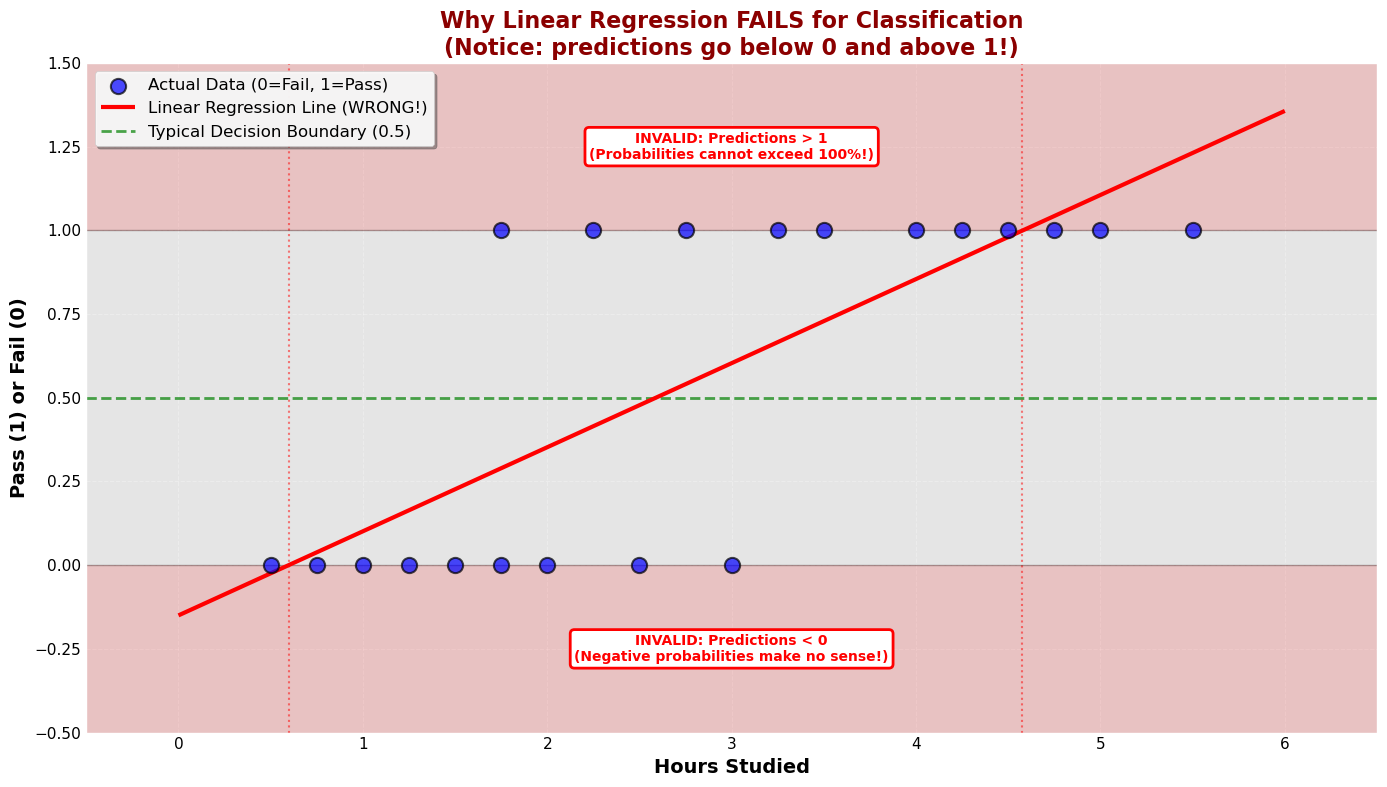


PROBLEMS WITH LINEAR REGRESSION FOR CLASSIFICATION

1. PREDICTIONS EXCEED VALID RANGE [0, 1]:
   Maximum prediction: 1.357
   Interpretation: '135.7%' probability?
   Minimum prediction: -0.150
   Interpretation: Negative probability?

2. NO TRUE PROBABILISTIC INTERPRETATION:
   Even predictions between 0 and 1 don't represent real probabilities
   They're just outputs of a linear function, not probability estimates

3. TREATS CATEGORICAL OUTCOME AS CONTINUOUS:
   Pass/Fail is binary, not a numerical scale
   There's no meaningful 'halfway between pass and fail'

4. VERY SENSITIVE TO OUTLIERS:
   One student who studied 10 hours and failed would tilt the entire line
   The model would make worse predictions for everyone

5. POOR DECISION BOUNDARY:
   The linear assumption doesn't match the abrupt change from fail to pass
   Real-world transitions are more gradual near the boundary

WE NEED A BETTER APPROACH → Enter Logistic Regression!


In [28]:
# Create a comprehensive visualization showing all the problems
plt.figure(figsize=(14, 8))

# Plot the actual data points
# These are the TRUE outcomes: 0 (fail) or 1 (pass)
# Blue dots at y=0 represent students who failed
# Blue dots at y=1 represent students who passed
plt.scatter(hours_studied, passed,
           color='blue', s=120, alpha=0.7, edgecolor='black', linewidth=1.5,
           label='Actual Data (0=Fail, 1=Pass)', zorder=5)

# Plot the linear regression line (the problematic approach)
# This red line shows what linear regression predicts
plt.plot(X_plot, y_pred_linear,
        color='red', linewidth=3, linestyle='-',
        label='Linear Regression Line (WRONG!)', zorder=3)

# Add a horizontal line at y=0.5 (typical decision boundary)
# If we use 0.5 as cutoff: predict "pass" if y ≥ 0.5, else predict "fail"
plt.axhline(y=0.5, color='green', linestyle='--', linewidth=2, alpha=0.7,
           label='Typical Decision Boundary (0.5)', zorder=2)

# Highlight the INVALID regions with red shading
# These regions show where predictions are impossible (< 0 or > 1)
plt.axhspan(-0.5, 0, alpha=0.15, color='red', zorder=1)
plt.axhspan(1, 1.5, alpha=0.15, color='red', zorder=1)

# Add text annotations to explain the problems
# These point out specific issues with the linear regression approach
plt.text(3, -0.25, 'INVALID: Predictions < 0\n(Negative probabilities make no sense!)',
        fontsize=10, color='red', fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2))

plt.text(3, 1.25, 'INVALID: Predictions > 1\n(Probabilities cannot exceed 100%!)',
        fontsize=10, color='red', fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2))

# Add vertical lines to show where predictions become invalid
# Left line: where predictions cross below 0
# Right line: where predictions cross above 1
invalid_below_indices = np.where(y_pred_linear < 0)[0]
invalid_above_indices = np.where(y_pred_linear > 1)[0]

if len(invalid_below_indices) > 0:
    boundary_low = X_plot[invalid_below_indices[-1] + 1, 0] if invalid_below_indices[-1] < len(X_plot)-1 else X_plot[invalid_below_indices[-1], 0]
    plt.axvline(x=boundary_low, color='red', linestyle=':', linewidth=1.5, alpha=0.5)

if len(invalid_above_indices) > 0:
    boundary_high = X_plot[invalid_above_indices[0] - 1, 0] if invalid_above_indices[0] > 0 else X_plot[invalid_above_indices[0], 0]
    plt.axvline(x=boundary_high, color='red', linestyle=':', linewidth=1.5, alpha=0.5)

# Labels and formatting
plt.xlabel('Hours Studied', fontsize=14, fontweight='bold')
plt.ylabel('Pass (1) or Fail (0)', fontsize=14, fontweight='bold')
plt.title('Why Linear Regression FAILS for Classification\n' +
         '(Notice: predictions go below 0 and above 1!)',
         fontsize=16, fontweight='bold', color='darkred')
plt.legend(fontsize=12, loc='upper left', framealpha=0.95)
plt.ylim(-0.5, 1.5)  # Extended range to show the problems
plt.xlim(-0.5, 6.5)  # Show full range including extremes
plt.grid(True, alpha=0.3, linestyle='--')

# Add horizontal lines at 0 and 1 to emphasize valid range
plt.axhline(y=0, color='black', linewidth=1, alpha=0.3)
plt.axhline(y=1, color='black', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed problems
print("\n" + "="*70)
print("PROBLEMS WITH LINEAR REGRESSION FOR CLASSIFICATION")
print("="*70)

print(f"\n1. PREDICTIONS EXCEED VALID RANGE [0, 1]:")
print(f"   Maximum prediction: {y_pred_linear.max():.3f}")
print(f"   Interpretation: '{y_pred_linear.max():.1%}' probability?")
print(f"   Minimum prediction: {y_pred_linear.min():.3f}")
print(f"   Interpretation: Negative probability?")

print(f"\n2. NO TRUE PROBABILISTIC INTERPRETATION:")
print(f"   Even predictions between 0 and 1 don't represent real probabilities")
print(f"   They're just outputs of a linear function, not probability estimates")

print(f"\n3. TREATS CATEGORICAL OUTCOME AS CONTINUOUS:")
print(f"   Pass/Fail is binary, not a numerical scale")
print(f"   There's no meaningful 'halfway between pass and fail'")

print(f"\n4. VERY SENSITIVE TO OUTLIERS:")
print(f"   One student who studied 10 hours and failed would tilt the entire line")
print(f"   The model would make worse predictions for everyone")

print(f"\n5. POOR DECISION BOUNDARY:")
print(f"   The linear assumption doesn't match the abrupt change from fail to pass")
print(f"   Real-world transitions are more gradual near the boundary")

print("\n" + "="*70)
print("WE NEED A BETTER APPROACH → Enter Logistic Regression!")
print("="*70)

### **The Problem**

Linear regression gives us predictions outside the range [0, 1], which doesn't make sense for probabilities! We need a function that:

1. **Outputs values between 0 and 1** (valid probabilities)
2. **Has an S-shaped curve** (gradual transition from 0 to 1)
3. **Can be interpreted as probability** of belonging to a class

Enter the **sigmoid function**!

---

## **1.3 The Sigmoid Function: The Heart of Logistic Regression**

### **1.3.1 Introduction to the Sigmoid Function**

We've seen that linear regression fails for classification because:
- Predictions can be < 0 or > 1
- No probabilistic interpretation
- Treats binary outcomes as continuous numbers

**What we need instead:** A function that:
- Always outputs values between 0 and 1 (valid probabilities)
- Has an S-shaped curve (smooth transition)
- Approaches 0 and 1 asymptotically (never quite reaches them)
- Is differentiable (needed for optimization)

**Enter the sigmoid function!** Also known as the **logistic function**.

### **1.3.2 Mathematical Definition**

The sigmoid function is defined as:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Breaking down this formula piece by piece:**

1. **$\sigma$ (lowercase sigma):** 
   - This is the name/symbol for the function
   - Pronounced "sigma"
   - Could also write it as $f(z)$ or $\text{sigmoid}(z)$

2. **$z$ (the input):**
   - Can be ANY real number: -1000, -5.3, 0, 2.7, 1000, etc.
   - No restrictions on input range
   - Domain: $(-\infty, +\infty)$

3. **$e$ (Euler's number):**
   - Mathematical constant ≈ 2.71828
   - Base of natural logarithm
   - Same $e$ used in calculus, compound interest, growth/decay

4. **$e^{-z}$ (e to the power of negative z):**
   - When z is large positive: $e^{-z}$ is very small (approaching 0)
   - When z is large negative: $e^{-z}$ is very large (approaching ∞)
   - When z = 0: $e^{0} = 1$

5. **$1 + e^{-z}$ (the denominator):**
   - Always positive (can't be zero or negative)
   - Always at least 1 (since $e^{-z} \geq 0$)

6. **$\frac{1}{1 + e^{-z}}$ (the complete function):**
   - Dividing 1 by a number ≥ 1 gives result ≤ 1
   - Result is always positive
   - Range: $(0, 1)$ (never exactly 0 or 1, but can get arbitrarily close)

### **1.3.3 Why This Formula Works**

Let's trace through what happens with different inputs:

**Case 1: Large positive z (e.g., z = 10)**
- $e^{-10} \approx 0.000045$ (very small)
- $1 + e^{-10} \approx 1.000045$ (barely more than 1)
- $\sigma(10) = \frac{1}{1.000045} \approx 0.9999$ (very close to 1)

**Case 2: Large negative z (e.g., z = -10)**
- $e^{-(-10)} = e^{10} \approx 22026$ (very large)
- $1 + e^{10} \approx 22027$ (very large)
- $\sigma(-10) = \frac{1}{22027} \approx 0.00005$ (very close to 0)

**Case 3: z = 0 (the midpoint)**
- $e^{0} = 1$ (exactly)
- $1 + 1 = 2$
- $\sigma(0) = \frac{1}{2} = 0.5$ (exactly halfway)

**Case 4: Moderate z (e.g., z = 2)**
- $e^{-2} \approx 0.1353$
- $1 + 0.1353 = 1.1353$
- $\sigma(2) = \frac{1}{1.1353} \approx 0.881$

### **1.3.4 Key Mathematical Properties**

The sigmoid function has several beautiful and useful properties:

#### **Property 1: Range is (0, 1)**
- **Output is ALWAYS between 0 and 1**
- Never exactly 0 or 1 (asymptotic)
- Perfect for representing probabilities!
- $\lim_{z \to -\infty} \sigma(z) = 0$
- $\lim_{z \to +\infty} \sigma(z) = 1$

#### **Property 2: Midpoint at (0, 0.5)**
- **When input is 0, output is exactly 0.5**
- $\sigma(0) = 0.5$
- This creates a natural decision boundary
- "Uncertainty point" - could go either way

#### **Property 3: Symmetry**
- **The function is symmetric around the midpoint**
- $\sigma(-z) = 1 - \sigma(z)$
- If P(class 1) = 0.7, then P(class 0) = 0.3
- Example: $\sigma(-2) = 1 - \sigma(2)$

#### **Property 4: S-Shaped Curve**
- **Sigmoidal (S-shaped) curve**
- Flat at extremes (high confidence)
- Steep in middle (transition zone)
- Smooth everywhere (no sharp corners)

#### **Property 5: Monotonically Increasing**
- **Always increasing** (never decreases)
- If $z_1 < z_2$, then $\sigma(z_1) < \sigma(z_2)$
- Larger input → larger output
- Preserves ordering

#### **Property 6: Differentiable Everywhere**
- **Has a derivative at every point**
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$
- This is crucial for gradient descent optimization
- Maximum slope at z = 0

### **1.3.5 Intuitive Understanding**

Think of the sigmoid function as a **"probability converter"**:

```
INPUT (z)              →  SIGMOID  →  OUTPUT (σ(z))
Any real number        →  Function →  Probability [0,1]

Examples:
z = -100 (very negative) → σ(z) ≈ 0.0000 → "Almost certainly class 0"
z = -5   (negative)      → σ(z) ≈ 0.0067 → "Very likely class 0"
z = -1   (slightly neg)  → σ(z) ≈ 0.2689 → "Probably class 0"
z = 0    (neutral)       → σ(z) = 0.5000 → "Uncertain, 50/50"
z = 1    (slightly pos)  → σ(z) ≈ 0.7311 → "Probably class 1"
z = 5    (positive)      → σ(z) ≈ 0.9933 → "Very likely class 1"
z = 100  (very positive) → σ(z) ≈ 1.0000 → "Almost certainly class 1"
```

**Interpretation for Classification:**
- **Large positive z**: Strong evidence for class 1 → probability near 1
- **Large negative z**: Strong evidence for class 0 → probability near 0
- **z near 0**: Weak evidence either way → probability near 0.5 (uncertain)

### **1.3.6 Historical Note**

**Why is it called "sigmoid"?**
- From Greek: σ (sigma) = the letter S
- "Sigmoid" means "S-shaped"
- The curve looks like the letter S

**Why is it also called "logistic"?**
- Comes from "logistic growth" models
- Used in population dynamics (Pierre François Verhulst, 1838)
- Describes growth that starts slow, accelerates, then levels off
- Same mathematical form

Now let's implement this function and see it in action!

In [ ]:
# Implement the sigmoid function from scratch
# This is the mathematical core of logistic regression!

def sigmoid(z):
    """
    Compute the sigmoid (logistic) function.

    The sigmoid function maps any real number to the range (0, 1),
    making it perfect for modeling probabilities in binary classification.

    Mathematical Formula:
    ---------------------
    σ(z) = 1 / (1 + e^(-z))

    Parameters:
    -----------
    z : float or array-like
        Input value(s). Can be:
        - A single number (int or float)
        - A NumPy array of any shape
        - A list (will be converted to array)

    Returns:
    --------
    float or array-like
        Sigmoid output(s), always between 0 and 1.
        Same shape as input.

    """
    # The implementation is beautifully simple - just one line!
    # 1 divided by (1 plus e to the power of negative z)
    return 1 / (1 + np.exp(-z))

# Test the function with a variety of inputs
# We'll test extreme values, moderate values, and the special case z=0
test_values = [-10, -5, -2, -1, 0, 1, 2, 5, 10]

print("="*80)
print("TESTING THE SIGMOID FUNCTION")
print("="*80)
print(f"\n{'z (input)':<12} {'σ(z) (output)':<20} {'Interpretation'}")
print("-"*80)

for val in test_values:
    output = sigmoid(val)

    # Provide interpretation based on the output value
    # This helps build intuition about what different probabilities mean
    if output < 0.01:
        interpretation = "Extremely confident: Class 0 (>99% sure)"
    elif output < 0.1:
        interpretation = "Very confident: Class 0 (~90-99% sure)"
    elif output < 0.3:
        interpretation = "Confident: Class 0 (~70-90% sure)"
    elif output < 0.4:
        interpretation = "Likely Class 0 (60-70% sure)"
    elif output < 0.6:
        interpretation = "Uncertain (near 50/50 - could go either way)"
    elif output < 0.7:
        interpretation = "Likely Class 1 (60-70% sure)"
    elif output < 0.9:
        interpretation = "Confident: Class 1 (~70-90% sure)"
    elif output < 0.99:
        interpretation = "Very confident: Class 1 (~90-99% sure)"
    else:
        interpretation = "Extremely confident: Class 1 (>99% sure)"

    print(f"{val:<12} {output:<20.10f} {interpretation}")

print("\n" + "="*80)
print("Function implemented and tested successfully!")
print("="*80)

TESTING THE SIGMOID FUNCTION

z (input)    σ(z) (output)        Interpretation
--------------------------------------------------------------------------------
-10          0.0000453979         Extremely confident: Class 0 (>99% sure)
-5           0.0066928509         Extremely confident: Class 0 (>99% sure)
-2           0.1192029220         Confident: Class 0 (~70-90% sure)
-1           0.2689414214         Confident: Class 0 (~70-90% sure)
0            0.5000000000         Uncertain (near 50/50 - could go either way)
1            0.7310585786         Confident: Class 1 (~70-90% sure)
2            0.8807970780         Confident: Class 1 (~70-90% sure)
5            0.9933071491         Extremely confident: Class 1 (>99% sure)
10           0.9999546021         Extremely confident: Class 1 (>99% sure)

Function implemented and tested successfully!


In [49]:
# Verify key mathematical properties
print("\n" + "="*80)
print("VERIFYING MATHEMATICAL PROPERTIES: Midpoint Property")
print("="*80)

# Property 1: σ(0) = 0.5
print("")
print(f"σ(0) = {sigmoid(0):.10f}")
print(f"Should be exactly 0.5: {'VERIFIED' if sigmoid(0) == 0.5 else 'FAILED'}")


VERIFYING MATHEMATICAL PROPERTIES: Midpoint Property

σ(0) = 0.5000000000
Should be exactly 0.5: VERIFIED


In [48]:
# Verify key mathematical properties
print("\n" + "="*80)
print("VERIFYING MATHEMATICAL PROPERTIES: Symmetry Property")
print("="*80)

# Property 2: Symmetry - σ(-z) = 1 - σ(z)
print("")
test_z = 3
sym_left = sigmoid(-test_z)
sym_right = 1 - sigmoid(test_z)
print(f"σ(-{test_z}) = {sym_left:.10f}")
print(f"1 - σ({test_z}) = {sym_right:.10f}")
print(f"Difference: {abs(sym_left - sym_right):.15f}")
print(f"Should be equal: {'VERIFIED' if np.isclose(sym_left, sym_right) else 'FAILED'}")


VERIFYING MATHEMATICAL PROPERTIES: Symmetry Property

σ(-3) = 0.0474258732
1 - σ(3) = 0.0474258732
Difference: 0.000000000000000
Should be equal: VERIFIED


In [60]:
# Verify key mathematical properties
print("\n" + "="*80)
print("VERIFYING MATHEMATICAL PROPERTIES: Range Property")
print("="*80)

# Property 3: Range is (0, 1)
print(f"")
extreme_values = np.array([-100, -50, 0, 50, 100])
extreme_outputs = sigmoid(extreme_values)
print(f"Testing extreme inputs: {extreme_values}")
print(f"All outputs in (0, 1): {'VERIFIED' if np.all((extreme_outputs > 0) & (extreme_outputs < 1)) else 'FAILED'}")
print(f"Min output: {extreme_outputs.min():.15f} (> 0)")
print(f"Max output: {extreme_outputs.max():.15f} (< 1)")


VERIFYING MATHEMATICAL PROPERTIES: Range Property

Testing extreme inputs: [-100  -50    0   50  100]
All outputs in (0, 1): FAILED
Min output: 0.000000000000000 (> 0)
Max output: 1.000000000000000 (< 1)


In [61]:
# Verify key mathematical properties
print("\n" + "="*80)
print("VERIFYING MATHEMATICAL PROPERTIES: Monotonic Property")
print("="*80)

# Property 4: Monotonically increasing
print("")
sequence = np.array([-5, -3, -1, 0, 1, 3, 5])
sequence_outputs = sigmoid(sequence)
is_increasing = np.all(np.diff(sequence_outputs) > 0)  # Check if always increasing
print(f"Input sequence: {sequence}")
print(f"Output sequence: {sequence_outputs}")
print(f"Always increasing: {'VERIFIED' if is_increasing else 'FAILED'}")


VERIFYING MATHEMATICAL PROPERTIES: Monotonic Property

Input sequence: [-5 -3 -1  0  1  3  5]
Output sequence: [0.00669285 0.04742587 0.26894142 0.5        0.73105858 0.95257413
 0.99330715]
Always increasing: VERIFIED


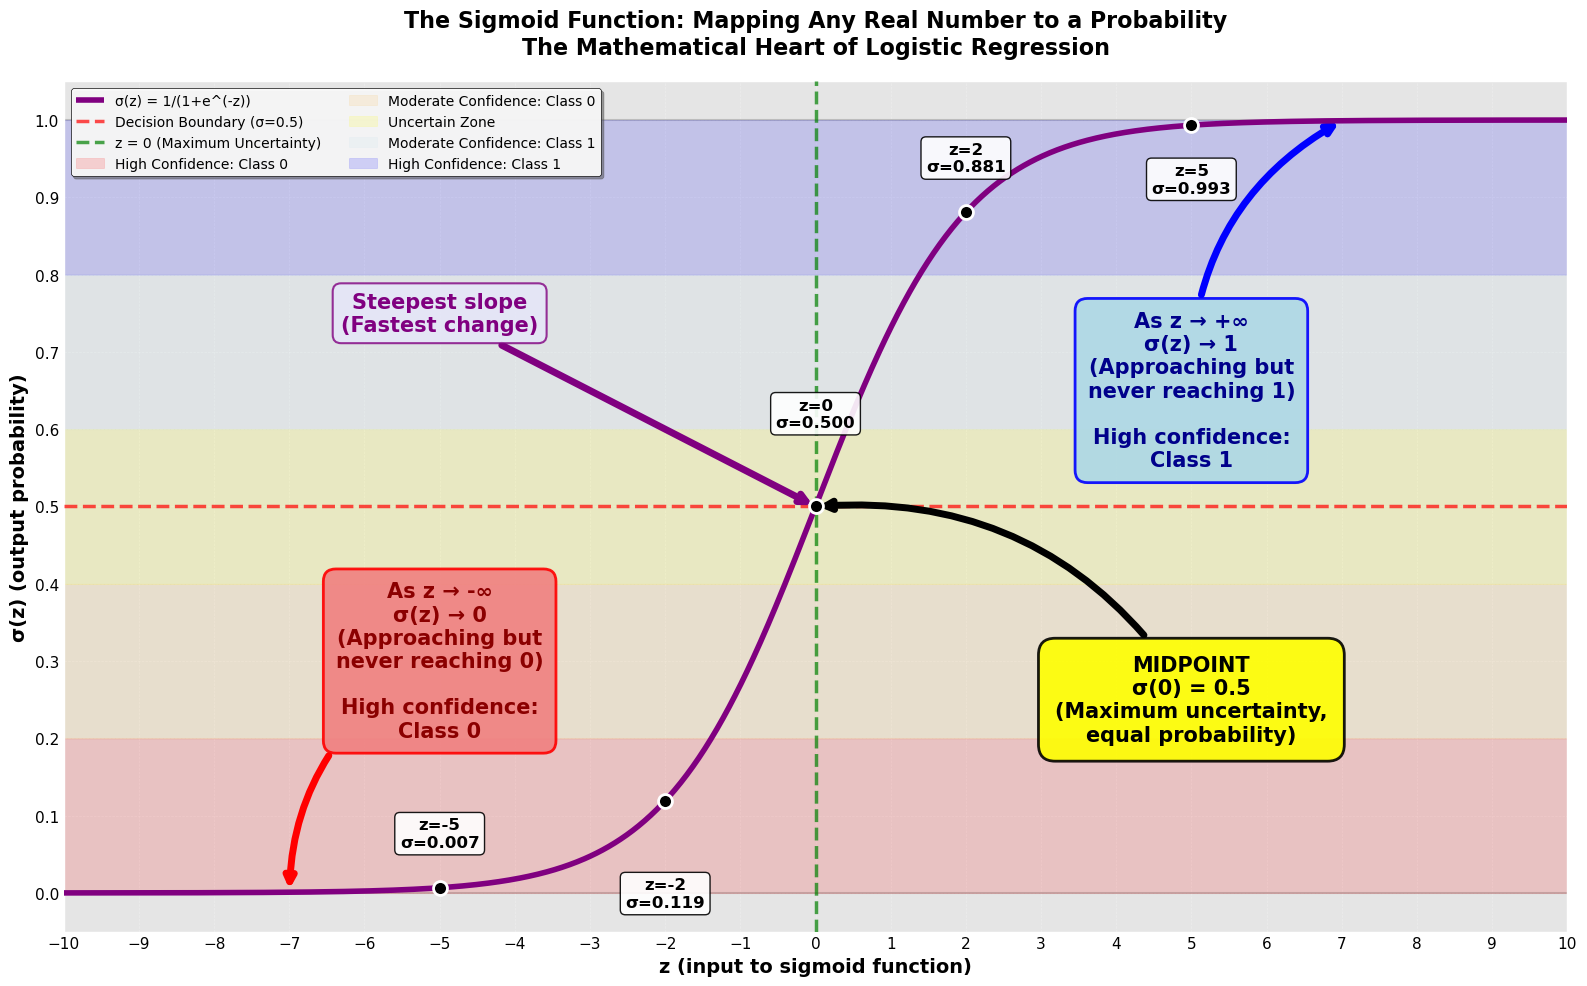

In [80]:
# Create a detailed, comprehensive visualization of the sigmoid function
# This plot will help build intuition about how sigmoid works

# Create input values spanning from very negative to very positive
z = np.linspace(-10, 10, 1000)

# Compute sigmoid values for all inputs
sigma_z = sigmoid(z)

# Create figure with larger size for better visibility
plt.figure(figsize=(16, 10))

# Plot the sigmoid curve itself
plt.plot(z, sigma_z, linewidth=4, color='purple',
        label='σ(z) = 1/(1+e^(-z))', zorder=5)

# ===================================================================
# Add reference lines to highlight key properties
# ===================================================================

# Horizontal line at 0.5 (decision boundary)
# This is where σ(z) = 0.5, the natural cutoff point
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2.5, alpha=0.7,
           label='Decision Boundary (σ=0.5)', zorder=3)

# Vertical line at z=0 (where σ=0.5)
# The sigmoid crosses 0.5 exactly when z=0
plt.axvline(x=0, color='green', linestyle='--', linewidth=2.5, alpha=0.7,
           label='z = 0 (Maximum Uncertainty)', zorder=3)

# Horizontal lines at 0 and 1 (asymptotes)
# Sigmoid approaches but never reaches these values
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1.5, alpha=0.4, zorder=1)
plt.axhline(y=1, color='gray', linestyle='-', linewidth=1.5, alpha=0.4, zorder=1)

# ===================================================================
# Add colored regions to show interpretation zones
# ===================================================================

# Region 1: High confidence for Class 0 (σ < 0.2)
plt.fill_between(z, 0, 0.2, alpha=0.15, color='red',
                label='High Confidence: Class 0', zorder=2)

# Region 2: Moderate confidence for Class 0 (0.2 ≤ σ < 0.4)
plt.fill_between(z, 0.2, 0.4, alpha=0.10, color='orange',
                label='Moderate Confidence: Class 0', zorder=2)

# Region 3: Uncertain zone (0.4 ≤ σ ≤ 0.6)
plt.fill_between(z, 0.4, 0.6, alpha=0.15, color='yellow',
                label='Uncertain Zone', zorder=2)

# Region 4: Moderate confidence for Class 1 (0.6 < σ ≤ 0.8)
plt.fill_between(z, 0.6, 0.8, alpha=0.10, color='lightblue',
                label='Moderate Confidence: Class 1', zorder=2)

# Region 5: High confidence for Class 1 (σ > 0.8)
plt.fill_between(z, 0.8, 1, alpha=0.15, color='blue',
                label='High Confidence: Class 1', zorder=2)

# ===================================================================
# Add annotations explaining key mathematical points
# ===================================================================

# Annotation 1: The midpoint (0, 0.5)
plt.annotate('MIDPOINT\nσ(0) = 0.5\n(Maximum uncertainty,\nequal probability)',
            xy=(0, 0.5), xytext=(5, 0.25), ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=5,
                          connectionstyle="arc3,rad=0.3"),
            fontsize=15, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow',
                     edgecolor='black', linewidth=2, alpha=0.9))

# Annotation 2: Upper asymptote (approaching 1)
plt.annotate('As z → +∞\nσ(z) → 1\n(Approaching but\nnever reaching 1)\n\nHigh confidence:\nClass 1',
            xy=(7, 0.999), xytext=(5, 0.65), ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='blue', lw=5,
                          connectionstyle="arc3,rad=-0.3"),
            fontsize=15, color='darkblue', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightblue',
                     edgecolor='blue', linewidth=2, alpha=0.9))

# Annotation 3: Lower asymptote (approaching 0)
plt.annotate('As z → -∞\nσ(z) → 0\n(Approaching but\nnever reaching 0)\n\nHigh confidence:\nClass 0',
            xy=(-7, 0.001), xytext=(-5, 0.3), ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='red', lw=5,
                          connectionstyle="arc3,rad=0.3"),
            fontsize=15, color='darkred', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightcoral',
                     edgecolor='red', linewidth=2, alpha=0.9))

# Annotation 4: Steepest slope point
plt.annotate('Steepest slope\n(Fastest change)',
            xy=(0, 0.5), xytext=(-5, 0.75), ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='purple', lw=5),
            fontsize=15, color='purple', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lavender',
                     edgecolor='purple', linewidth=1.5, alpha=0.8))

# ===================================================================
# Mark specific important points on the curve
# ===================================================================

# Mark several key points with dots and labels
special_points = [
    (-5, 'z=-5', 0.07),
    (-2, 'z=-2', -0.12),
    (0, 'z=0', 0.12),
    (2, 'z=2', 0.07),
    (5, 'z=5', -0.07)
]

for z_val, label_text, offset_y  in special_points:
    y_val = sigmoid(z_val)
    # Plot the point
    plt.plot(z_val, y_val, 'ko', markersize=10, zorder=6,
            markeredgecolor='white', markeredgewidth=2)
    # Add label
    plt.text(z_val, y_val + offset_y,
            f'{label_text}\nσ={y_val:.3f}', va='center',
            ha='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     edgecolor='black', linewidth=1, alpha=0.9), zorder=99)

# ===================================================================
# Labels, title, and formatting
# ===================================================================

plt.xlabel('z (input to sigmoid function)', fontsize=14, fontweight='bold')
plt.ylabel('σ(z) (output probability)', fontsize=14, fontweight='bold')
plt.title('The Sigmoid Function: Mapping Any Real Number to a Probability\n' +
         'The Mathematical Heart of Logistic Regression',
         fontsize=16, fontweight='bold', pad=20)

# Create legend with two columns for better space usage
plt.legend(fontsize=10, loc='upper left', ncol=2, framealpha=0.95,
          edgecolor='black', fancybox=True)

# Grid for easier reading
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Set axis limits
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 10)

# Add ticks for better readability
plt.xticks(np.arange(-10, 11, 1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.tight_layout()
plt.show()

### **1.3.7 Key Mathematical Properties (Summary)**

#### **Range: (0, 1) - Perfect for Probabilities**
* Never exactly 0 or 1 (asymptotic)
* Always a valid probability value
* Reflects epistemic humility (never 100% certain)

#### **Midpoint ($\sigma(0) = 0.5$) - Natural Decision Boundary**
* When $z=0$, probability is exactly 50/50
* This creates a default threshold
* Maximum uncertainty point

#### **Symmetry ($\sigma(-z) = 1 - \sigma(z)$)**
* Symmetric around the midpoint
* If $\text{P(class 1)} = 0.7$&nbsp;&nbsp;then&nbsp;&nbsp;$\text{P(class 0)} = 0.3$
* Only need to compute one; Get the other for free

#### **S-Shape: Sigmoidal Curve**
* Flat at extremes (confident predictions)
* Steep in the middle (transition zone)
* Smooth everywhere (no discontinuities)
* Steepest at $z=0$ (maximum rate of change)

#### **Monotonic: Always Increasing**
* Larger $z$ always gives larger $\sigma(z)$
* Preserves ordering of inputs
* More evidence → higher probability

#### **Differentiable: Smooth for optimization**
* Derivative exists everywhere
* $\sigma^\prime(z) = \sigma(z)(1 - \sigma(z))$
* Critical for gradient descent training

### **1.3.8 Why This Matters for Classification**
* Outputs are interpretable as probabilities
* Smooth transition reflects real-world uncertainty
* Can use threshold (e.g., 0.5) to make binary descisions
* Extreme inputs give confident predictions (near 0 or 1)
* Inputs near 0 give uncertain predictions (near 0.5)
* Differentiable so we can train with gradient descent
* Never claims 100% certainty (epistemic humility)

---

## **1.4 Logistic Regression: Combining Linear Models with Sigmoid**

### **1.4.1 The Big Idea**

Now we're ready to understand **logistic regression**!

**Logistic regression combines two things we already understand:**

1. **Linear combination of features** (exactly like linear regression)
   - We create a weighted sum of our input features
   - Each feature has a coefficient (weight)
   - There's an intercept (bias) term

2. **Sigmoid function** (to convert to probabilities)
   - Take the linear combination
   - Pass it through sigmoid
   - Get a probability between 0 and 1

### **1.4.2 The Mathematical Formula**

**For a single feature (like our exam hours example):**

$$P(y=1|x) = \sigma(\beta_0 + \beta_1 x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

**For multiple features (more realistic):**

$$P(y=1|X) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n)$$

**Or more compactly using vector notation:**

$$P(y=1|X) = \sigma(\beta_0 + \beta^T X) = \frac{1}{1 + e^{-(\beta_0 + \beta^T X)}}$$

#### **Breaking Down Each Component**

##### **1. $P(y=1|X)$ - The output**
- Probability that y equals 1, given features X
- "Given what we know about this data point, what's the probability it's class 1?"
- Between 0 and 1 (valid probability)
- This is what we want to predict

##### **2. $\beta_0$ - The intercept (bias term)**
- Baseline log-odds when all features are 0
- Shifts the sigmoid curve left or right
- Learned from data during training
- **Interpretation:** 
  - If $\beta_0 > 0$: bias toward class 1
  - If $\beta_0 < 0$: bias toward class 0
  - If $\beta_0 = 0$: no baseline bias

##### **3. $\beta_1, \beta_2, \ldots, \beta_n$ - Feature coefficients (weights)**
- How much each feature affects the outcome
- Learned from data during training
- **Interpretation:**
  - **Positive coefficient**: Higher feature value → higher probability of class 1
    - Example: More study hours → higher probability of passing
  - **Negative coefficient**: Higher feature value → lower probability of class 1
    - Example: More missed classes → lower probability of passing
  - **Larger magnitude**: Stronger effect on outcome
  - **Zero coefficient**: Feature doesn't affect outcome (could be removed)

##### **4. $x_1, x_2, \ldots, x_n$ - The feature values**
- Input data about a specific instance
- What we know about this particular case
- Examples:
  - Hours studied, previous GPA, attendance rate
  - Age, income, credit score
  - Email length, number of links, sender domain

##### **5. $\sigma()$ - The sigmoid function**
- Wraps the entire linear combination
- Converts any number to a probability
- This is what makes it "logistic" regression!

### **1.4.3 The Two-Step Process in Detail**

#### **Step 1: Compute the linear combination (z)**

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

- This is EXACTLY like linear regression
- Weighted sum of features plus intercept
- Can be any real number (negative, zero, positive, large, small)
- This $z$ represents the **log-odds** (more on this later)

**Example calculation:**
- Features: $x_1 = 3$ hours studied, $x_2 = 0.8$ (GPA on 0-1 scale)
- Coefficients: $\beta_0 = -2$, $\beta_1 = 0.5$, $\beta_2 = 2$
- Calculation:
  $$z = -2 + 0.5(3) + 2(0.8) = -2 + 1.5 + 1.6 = 1.1$$

#### **Step 2: Apply sigmoid to get probability**

$$P(y=1|X) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

- Take the $z$ from step 1
- Pass it through sigmoid
- Get a probability

**Continuing our example:**
- $z = 1.1$
- $P(y=1|X) = \sigma(1.1) = \frac{1}{1 + e^{-1.1}} \approx 0.75$
- **Interpretation:** 75% probability of passing

#### **Step 3: Make a decision (convert probability to prediction)**

$$\hat{y} = \begin{cases} 
1 & \text{if } P(y=1|X) \geq \text{threshold} \\
0 & \text{if } P(y=1|X) < \text{threshold}
\end{cases}$$

- Typically threshold = 0.5 (but adjustable)
- Convert probability to binary prediction

**Completing our example:**
- P = 0.75
- 0.75 ≥ 0.5 (threshold)
- Therefore: $\hat{y} = 1$ (predict "pass")

### **1.4.4 Comparing to Linear Regression**

**Linear Regression:**  
Features → Linear Combination → Output ... aka ... (X → β₀ + β₁x₁ + ... + βₙxₙ → ŷ)
- Output can be any number (-∞ to +∞)
- Used for continuous predictions
- Loss function: Mean Squared Error (MSE)

**Logistic Regression:**  
Features → Linear Combination → Sigmoid → Probability → Class ... aka ... X → z = β₀ + β₁x₁ + ... + βₙxₙ → σ(z) → P ∈ (0,1) → 0 or 1
- Output is probability (0 to 1)
- Used for classification
- Loss function: Log-loss (Cross-Entropy)

**Key Difference:**
The sigmoid function "squashes" the linear output into a valid probability!

Now let's see this in action on our exam data!


In [83]:
# Fit logistic regression to our exam data (CORRECT approach)
# This is what we should have done from the beginning!

# Create and train the logistic regression model
# LogisticRegression() uses several defaults:
#   - solver='lbfgs': optimization algorithm (L-BFGS-B)
#   - max_iter=100: maximum number of iterations
#   - C=1.0: inverse of regularization strength (we'll discuss later)
log_reg = LogisticRegression()

# Fit the model to our training data
log_reg.fit(X, y)

# Generate predictions across a wide range for visualization
X_plot = np.linspace(0, 6, 300).reshape(-1, 1)

# Get PROBABILITY predictions from logistic regression
# predict_proba() returns array with shape (n_samples, 2)
#   Column 0: P(y=0|X) - probability of class 0
#   Column 1: P(y=1|X) - probability of class 1
# We want column 1 (probability of passing)
y_prob_logistic = log_reg.predict_proba(X_plot)[:, 1]

# Get CLASS predictions (0 or 1) using default threshold of 0.5
# This is what predict() does: if prob ≥ 0.5, return 1, else return 0
y_pred_class = log_reg.predict(X_plot)

In [84]:
# Display the learned model parameters
print("="*80)
print("LOGISTIC REGRESSION MODEL FITTED SUCCESSFULLY")
print("="*80)

print("\nModel Parameters (Learned from Data):")
print("-"*80)
print(f"Intercept (β₀):    {log_reg.intercept_[0]:.6f}")
print(f"Coefficient (β₁):  {log_reg.coef_[0][0]:.6f}")

print("\nModel Equation:")
print("-"*80)
print(f"z = {log_reg.intercept_[0]:.4f} + {log_reg.coef_[0][0]:.4f} × hours")
print(f"P(pass | hours) = σ(z) = 1 / (1 + e^(-z))")
print(f"\nOr written out fully:")
print(f"P(pass | hours) = 1 / (1 + e^(-({log_reg.intercept_[0]:.4f} + {log_reg.coef_[0][0]:.4f} × hours)))")

LOGISTIC REGRESSION MODEL FITTED SUCCESSFULLY

Model Parameters (Learned from Data):
--------------------------------------------------------------------------------
Intercept (β₀):    -3.346382
Coefficient (β₁):  1.363497

Model Equation:
--------------------------------------------------------------------------------
z = -3.3464 + 1.3635 × hours
P(pass | hours) = σ(z) = 1 / (1 + e^(-z))

Or written out fully:
P(pass | hours) = 1 / (1 + e^(-(-3.3464 + 1.3635 × hours)))


In [85]:
# Interpret the coefficients
print("\n" + "="*80)
print("INTERPRETATION OF COEFFICIENTS")
print("="*80)

print(f"\n1. INTERCEPT (β₀ = {log_reg.intercept_[0]:.4f}):")
if log_reg.intercept_[0] < 0:
    print(f"   • NEGATIVE intercept means:")
    print(f"   • When hours = 0, z = {log_reg.intercept_[0]:.4f} (negative)")
    print(f"   • Therefore P(pass) = σ({log_reg.intercept_[0]:.4f}) ≈ {sigmoid(log_reg.intercept_[0]):.1%}")
    print(f"   • This makes sense: with zero study, low probability of passing ✓")
else:
    print(f"   • POSITIVE intercept means baseline tendency toward passing")
    print(f"   • Even with hours = 0, some probability of passing")

print(f"\n2. COEFFICIENT (β₁ = {log_reg.coef_[0][0]:.4f}):")
if log_reg.coef_[0][0] > 0:
    print(f"   • POSITIVE coefficient means:")
    print(f"   • More study hours → Higher z → Higher P(pass) ✓")
    print(f"   • Each additional hour studied increases log-odds of passing by {log_reg.coef_[0][0]:.4f}")
    print(f"   • This makes intuitive sense: studying helps! ✓")
else:
    print(f"   • NEGATIVE coefficient would mean studying hurts (unexpected!)")


INTERPRETATION OF COEFFICIENTS

1. INTERCEPT (β₀ = -3.3464):
   • NEGATIVE intercept means:
   • When hours = 0, z = -3.3464 (negative)
   • Therefore P(pass) = σ(-3.3464) ≈ 3.4%
   • This makes sense: with zero study, low probability of passing ✓

2. COEFFICIENT (β₁ = 1.3635):
   • POSITIVE coefficient means:
   • More study hours → Higher z → Higher P(pass) ✓
   • Each additional hour studied increases log-odds of passing by 1.3635
   • This makes intuitive sense: studying helps! ✓


In [87]:
# Show example predictions at specific study hours
print("\n" + "="*80)
print("EXAMPLE PREDICTIONS AT DIFFERENT STUDY HOURS")
print("="*80)
print(f"\n{'Hours':<8} {'z value':<12} {'P(pass)':<12} {'Prediction':<12} {'Confidence'}")
print("-"*80)

test_hours_examples = [0, 1, 2, 3, 4, 5, 6]
for hours in test_hours_examples:
    # Calculate z (linear combination)
    z_val = log_reg.intercept_[0] + log_reg.coef_[0][0] * hours

    # Calculate probability
    prob = sigmoid(z_val)

    # Determine prediction
    pred = "PASS" if prob >= 0.5 else "FAIL"

    # Assess confidence
    if prob >= 0.9 or prob <= 0.1:
        confidence = "Very High"
    elif prob >= 0.7 or prob <= 0.3:
        confidence = "High"
    elif prob >= 0.6 or prob <= 0.4:
        confidence = "Moderate"
    else:
        confidence = "Low (uncertain)"

    print(f"{hours:<8} {z_val:<12.4f} {prob:<12.1%} {pred:<12} {confidence}")

print("\n" + "="*80)
print("Logistic regression provides meaningful probabilities!")
print("All probabilities are between 0 and 1!")
print("Coefficients align with intuitions!")
print("="*80)


EXAMPLE PREDICTIONS AT DIFFERENT STUDY HOURS

Hours    z value      P(pass)      Prediction   Confidence
--------------------------------------------------------------------------------
0        -3.3464      3.4%         FAIL         Very High
1        -1.9829      12.1%        FAIL         High
2        -0.6194      35.0%        FAIL         Moderate
3        0.7441       67.8%        PASS         Moderate
4        2.1076       89.2%        PASS         High
5        3.4711       97.0%        PASS         Very High
6        4.8346       99.2%        PASS         Very High

Logistic regression provides meaningful probabilities!
All probabilities are between 0 and 1!
Coefficients align with intuitions!


#### **Understanding the Model Output**

**Let's deeply analyze what the model learned:**

##### **The Intercept (β₀)**

**What it represents:**
- The log-odds of passing when hours = 0
- Shifts the entire sigmoid curve left or right
- Captures baseline probability before considering study hours

**Typical values and interpretation:**
- **β₀ = -3:** Very negative
  - When hours = 0: z = -3, P(pass) ≈ 4.7%
  - Means: Without studying, very unlikely to pass
  - This would make sense for a very difficult exam

- **β₀ = 0:** Neutral
  - When hours = 0: z = 0, P(pass) = 50%
  - Means: Without studying, it's a coin flip
  - This would make sense for a very easy exam or very well-prepared students

- **β₀ = +3:** Very positive
  - When hours = 0: z = 3, P(pass) ≈ 95.3%
  - Means: Even without studying, very likely to pass
  - This would be unusual unless students are very well-prepared already

##### **The Coefficient (β₁)**

**What it represents:**
- How much each additional hour of study changes the log-odds
- The slope of the linear component (before sigmoid)
- Determines how steeply probability changes with study hours

**Magnitude interpretation:**
- **|β₁| is large (e.g., 2.0):** Study hours have strong effect
  - Steep sigmoid curve
  - Sharp transition from fail to pass
  - Study hours are very predictive

- **|β₁| is moderate (e.g., 0.5):** Study hours have moderate effect
  - Gradual sigmoid curve
  - Smooth transition from fail to pass
  - Study hours are somewhat predictive

- **|β₁| is small (e.g., 0.1):** Study hours have weak effect
  - Very gradual sigmoid curve
  - Study hours barely affect outcome
  - Other factors matter more

**Sign interpretation:**
- **β₁ > 0:** More hours → Higher probability of passing ✓
- **β₁ < 0:** More hours → Lower probability of passing ✗ (Would be very unusual!)

##### **Example Calculation Walkthrough**

Let's say our model learned: β₀ = -3.5, β₁ = 1.2

**Student who studied 3 hours:**
1. Calculate z:
   - z = β₀ + β₁ × hours
   - z = -3.5 + 1.2 × 3
   - z = -3.5 + 3.6
   - z = 0.1

2. Apply sigmoid:
   - P(pass) = σ(0.1)
   - P(pass) = 1 / (1 + e^(-0.1))
   - P(pass) ≈ 0.525 = 52.5%

3. Make decision:
   - 0.525 ≥ 0.5 (threshold)
   - Predict: PASS
   - But barely! Low confidence.

**Student who studied 5 hours:**
1. z = -3.5 + 1.2 × 5 = -3.5 + 6.0 = 2.5
2. P(pass) = σ(2.5) ≈ 0.924 = 92.4%
3. Predict: PASS (high confidence)

**Student who studied 1 hour:**
1. z = -3.5 + 1.2 × 1 = -3.5 + 1.2 = -2.3
2. P(pass) = σ(-2.3) ≈ 0.091 = 9.1%
3. Predict: FAIL (high confidence)

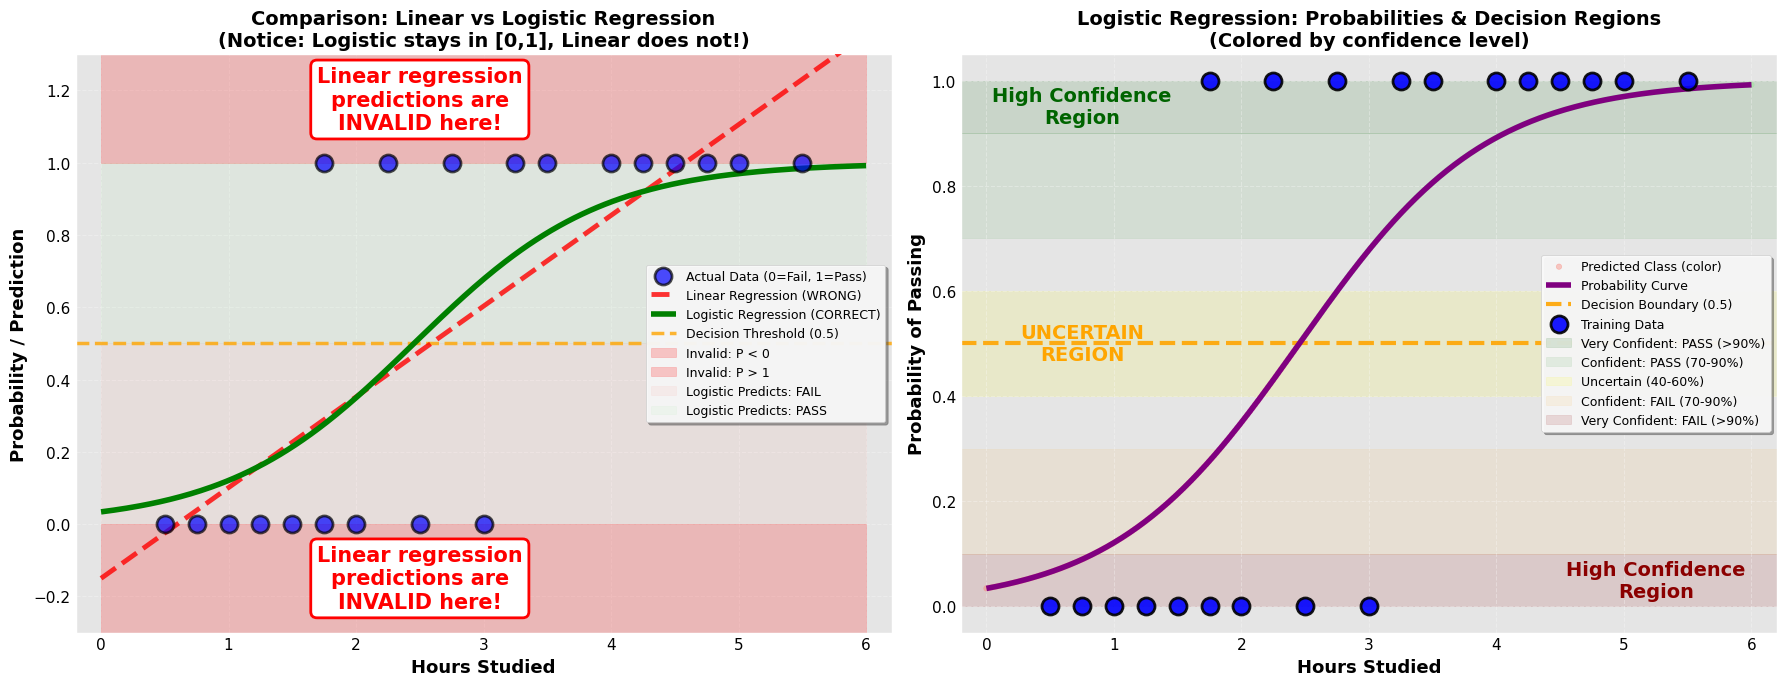

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================================
# LEFT PLOT: Direct Comparison of Linear vs. Logistic Regression
# ============================================================================

# Plot actual data points
# These are the ground truth: students who actually passed (1) or failed (0)
ax1.scatter(hours_studied, passed, color='blue', s=150, alpha=0.7,
           edgecolor='black', linewidth=2, label='Actual Data (0=Fail, 1=Pass)',
           zorder=5)

# Plot linear regression line (the WRONG approach)
# Notice how it extends beyond [0, 1] bounds
ax1.plot(X_plot, y_pred_linear, color='red', linewidth=3.5,
        label='Linear Regression (WRONG)', alpha=0.8, linestyle='--',
        zorder=3)

# Plot logistic regression curve (the CORRECT approach)
# Notice how it stays perfectly within [0, 1] bounds
ax1.plot(X_plot, y_prob_logistic, color='green', linewidth=4,
        label='Logistic Regression (CORRECT)', zorder=4)

# Add decision boundary at 0.5
# This is where we switch from predicting "fail" to "pass"
ax1.axhline(y=0.5, color='orange', linestyle='--', linewidth=2.5,
           alpha=0.8, label='Decision Threshold (0.5)', zorder=2)

# Shade the INVALID regions (where linear regression fails)
# These regions show probabilities < 0 or > 1, which are impossible
ax1.fill_between(X_plot.ravel(), -0.3, 0, alpha=0.2, color='red',
                label='Invalid: P < 0', zorder=1)
ax1.fill_between(X_plot.ravel(), 1, 1.3, alpha=0.2, color='red',
                label='Invalid: P > 1', zorder=1)

# Shade decision regions for logistic regression
ax1.fill_between(X_plot.ravel(), 0, 0.5, alpha=0.08, color='salmon',
                label='Logistic Predicts: FAIL', zorder=1)
ax1.fill_between(X_plot.ravel(), 0.5, 1, alpha=0.08, color='lightgreen',
                label='Logistic Predicts: PASS', zorder=1)

# Add annotation showing the problem with linear regression
# ax1.annotate('Linear regression\npredictions are\nINVALID here!',
#             xy=(0.5, -0.15), xytext=(2.5, -0.15), ha='center', va='center',
#             arrowprops=dict(arrowstyle='->', color='red', lw=4),
#             fontsize=15, color='red', fontweight='bold',
#             bbox=dict(boxstyle='round', facecolor='white',
#                      edgecolor='red', linewidth=2))
textbox = 'Linear regression\npredictions are\nINVALID here!'
bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2)
ax1.text(2.5, -0.15, textbox, va='center', ha='center', color='red',
        fontsize=15, fontweight='bold', bbox=bbox, zorder=99)
ax1.text(2.5, 1.175, textbox, va='center', ha='center', color='red',
        fontsize=15, fontweight='bold', bbox=bbox, zorder=99)


# Labels and formatting for left plot
ax1.set_xlabel('Hours Studied', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability / Prediction', fontsize=13, fontweight='bold')
ax1.set_title('Comparison: Linear vs Logistic Regression\n' +
             '(Notice: Logistic stays in [0,1], Linear does not!)',
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='center right', framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim(-0.3, 1.3)
ax1.set_xlim(-0.2, 6.2)

# ============================================================================
# RIGHT PLOT: Detailed View of Logistic Regression
# ============================================================================

# Create colored background showing predicted classes
# Everything below 0.5 predicts FAIL (red background)
# Everything above 0.5 predicts PASS (green background)
colors_pred = ['salmon' if pred == 0 else 'lightgreen' for pred in y_pred_class]
ax2.scatter(X_plot, y_prob_logistic, c=colors_pred, s=15, alpha=0.4,
           label='Predicted Class (color)', zorder=1)

# Plot the main probability curve
ax2.plot(X_plot, y_prob_logistic, color='purple', linewidth=4,
        label='Probability Curve', zorder=3)

# Add decision threshold line
ax2.axhline(y=0.5, color='orange', linestyle='--', linewidth=3,
           alpha=0.9, label='Decision Boundary (0.5)', zorder=2)

# Plot actual training data on top
# This allows us to see how well the model fits
ax2.scatter(hours_studied, passed, color='blue', s=150, alpha=0.9,
           edgecolor='black', linewidth=2, label='Training Data', zorder=5)

# Add confidence level regions with shading
# These help interpret how certain the model is
ax2.axhspan(0.9, 1.0, alpha=0.12, color='darkgreen',
           label='Very Confident: PASS (>90%)', zorder=0)
ax2.axhspan(0.7, 0.9, alpha=0.08, color='green',
           label='Confident: PASS (70-90%)', zorder=0)
ax2.axhspan(0.4, 0.6, alpha=0.12, color='yellow',
           label='Uncertain (40-60%)', zorder=0)
ax2.axhspan(0.1, 0.3, alpha=0.08, color='orange',
           label='Confident: FAIL (70-90%)', zorder=0)
ax2.axhspan(0.0, 0.1, alpha=0.12, color='darkred',
           label='Very Confident: FAIL (>90%)', zorder=0)

# Add annotations explaining key regions
ax2.annotate('High Confidence\nRegion',
            xy=(0.75, 0.95), fontsize=14, ha='center', va='center',
            color='darkgreen', fontweight='bold')
ax2.annotate('High Confidence\nRegion',
            xy=(5.25, 0.05), fontsize=14, ha='center', va='center',
            color='darkred', fontweight='bold')
ax2.annotate('UNCERTAIN\nREGION',
            xy=(0.75, 0.5), fontsize=14, ha='center', va='center',
            color='orange', fontweight='bold')

# Labels and formatting for right plot
ax2.set_xlabel('Hours Studied', fontsize=13, fontweight='bold')
ax2.set_ylabel('Probability of Passing', fontsize=13, fontweight='bold')
ax2.set_title('Logistic Regression: Probabilities & Decision Regions\n' +
             '(Colored by confidence level)',
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='center right', framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlim(-0.2, 6.2)

plt.tight_layout()
plt.show()

### **1.4.5 Key Advantages of Logistic Regression**
* Always outputs valid probabilities (0 to 1)
* S-shaped curve fits binary data naturally
* Provides confidence in predictions (not just yes/no)
* Probabilistic interpretation is meaningful
* Can adjust decision threshold based on context
* Captures uncertainty in transition zones
* Mathematically sound for classification


---

## **1.5 Decision Thresholds: From Probability to Prediction**

### **1.5.1 The Classification Decision**

**The fundamental question:**

Logistic regression gives us **probabilities** (continuous values from 0 to 1).  
But we often need **class predictions** (discrete: 0 or 1, pass or fail).  
**How do we convert probabilities to decisions?**

**Answer:** We use a **decision threshold** (also called cutoff, decision boundary, or classification threshold).

### **1.5.2 The Default Threshold: 0.5**

**Standard approach:**

$$\hat{y} = \begin{cases} 
1 & \text{if } P(y=1|X) \geq 0.5 \\
0 & \text{if } P(y=1|X) < 0.5
\end{cases}$$

**In plain English:**
- If probability ≥ 50%, predict positive class (1)
- If probability < 50%, predict negative class (0)
- This is sklearn's default when you call `.predict()`

**Why 0.5 is "natural":**
- It's the midpoint of the sigmoid function
- When z = 0, σ(z) = 0.5 exactly
- Treats both classes equally
- "More likely to be 1 than 0? Predict 1."

#### **But 0.5 is NOT Always the Best Choice!**

**Critical insight:** The optimal threshold depends on your **business context** and **cost of errors**.


### **1.5.3 Factors That Determine Optimal Threshold**

#### **1.5.3.1 Cost of Errors (Most Important!)**

**Two types of errors:**

**False Positive (Type I Error):**
- Predict positive when actually negative
- Example: Diagnose healthy person as sick
- Example: Mark legitimate email as spam
- Example: Approve bad loan

**False Negative (Type II Error):**
- Predict negative when actually positive
- Example: Miss diagnosing sick person
- Example: Let spam through
- Example: Deny good loan

**Key question:** Which error is more costly?

**If false negatives are more costly → Use LOWER threshold**
- Be more willing to predict positive
- Accept more false positives to avoid missing true positives
- Examples: Medical diagnosis, fraud detection

**If false positives are more costly → Use HIGHER threshold**
- Be more conservative about predicting positive
- Accept missing some true positives to avoid false positives
- Examples: Spam detection, judicial decisions

#### **1.5.3.2 Class Imbalance**

**When classes are imbalanced:**
- If positive class is rare (e.g., 5% of data)
- Model probabilities might be "calibrated" differently
- May need to adjust threshold accordingly

**Example:**
- Disease affects 1% of population
- Model might never predict > 0.3 probability
- Using threshold of 0.5 would catch nothing!
- Might need threshold of 0.1 or 0.15

#### **1.5.3.3 Business Goals and Constraints**

**Resource limitations:**
- Can only contact X customers for retention
- Can only investigate Y fraud cases
- Set threshold to get desired number of positives

**Performance metrics:**
- Want to maximize precision? Use higher threshold
- Want to maximize recall? Use lower threshold
- Want to balance both? Optimize F1-score (Week 7!)

### **1.5.4 Real-World Threshold Examples**

Let's explore concrete examples from different domains:

#### **Example 1: Medical Diagnosis (Lower Threshold)**

**Scenario:** Diagnosing a serious disease

**Cost Analysis:**
- **False Positive:** Patient gets unnecessary follow-up test
  - Cost: $500 test, some stress
  - Severity: Minor inconvenience
- **False Negative:** Miss sick patient
  - Cost: Disease progresses untreated
  - Severity: Potentially fatal

**Decision:** Use threshold = 0.2 or 0.3 (LOWER than default)

**Reasoning:**
- Even 20-30% probability warrants follow-up
- Better to do 10 unnecessary tests than miss 1 sick person
- Follow-up test is confirmatory anyway
- "When in doubt, check it out"

**Impact:**
- More false positives (more follow-up tests)
- But far fewer false negatives (rarely miss sick people)
- Appropriate trade-off for medical context

#### **Example 2: Spam Email Detection (Higher Threshold)**

**Scenario:** Filtering spam emails

**Cost Analysis:**
- **False Positive:** Important email goes to spam
  - Cost: Miss job offer, important meeting, client communication
  - Severity: Potentially very high
  - User trust in system destroyed
- **False Negative:** Spam gets through
  - Cost: User has to delete it manually
  - Severity: Minor annoyance

**Decision:** Use threshold = 0.7 or 0.8 (HIGHER than default)

**Reasoning:**
- Must be very confident before marking as spam
- Users can tolerate some spam in inbox
- Users CANNOT tolerate missing important emails
- Trust is paramount

**Impact:**
- More spam gets through (more false negatives)
- But almost never block important emails (few false positives)
- User maintains trust in email system

#### **Example 3: Fraud Detection (Lower Threshold)**

**Scenario:** Detecting credit card fraud

**Cost Analysis:**
- **False Positive:** Flag legitimate transaction
  - Cost: Temporarily decline card, customer calls
  - Severity: Minor inconvenience, quickly resolved
- **False Negative:** Miss fraudulent charge
  - Cost: Customer loses money, bank liable
  - Severity: Significant financial loss

**Decision:** Use threshold = 0.3 or 0.4 (LOWER than default)

**Reasoning:**
- Even 30% probability of fraud worth investigating
- Can verify suspicious transactions quickly
- Cost of investigation << cost of fraud
- Better safe than sorry

**Impact:**
- More legitimate transactions flagged
- But catch much more fraud
- Net positive for bank and customers

#### **Example 4: Loan Approval (Balanced Threshold)**

**Scenario:** Approving personal loans

**Cost Analysis:**
- **False Positive:** Approve risky borrower
  - Cost: Loan defaults, lose principal + interest
  - Severity: Direct financial loss
- **False Negative:** Reject good borrower
  - Cost: Miss out on interest income
  - Severity: Opportunity cost, customer dissatisfaction

**Decision:** Use threshold = 0.5 to 0.6 (near default, slight adjustment)

**Reasoning:**
- Costs are more balanced here
- Both errors have financial impact
- Can optimize threshold for maximum profit
- Might adjust slightly based on current portfolio

**Impact:**
- Balanced approach
- Optimize overall financial return
- May adjust threshold based on economic conditions

### **1.5.5 The Fundamental Trade-Off**

**You CANNOT optimize everything simultaneously!**

LOWER Threshold (e.g., 0.3) $\longrightarrow$ More Positive Predictions $\longrightarrow$ Catch more true positives (higher recall/sensitivity) but also more false positives (lower precision)  
  
Use when: Missing positives is very costly  
Examples: Medical diagnosis, fraud detection, safety systems  

HIGHER Threshold (e.g., 0.7) $\longrightarrow$ Fewer Positive Predictions $\longrightarrow$ Fewer false positives (higher precision) but Miss more true positives (lower recall/sensitivity)  
  
Use when: False positives are very costly  
Examples: Spam detection, judicial decisions, marketing campaigns  

**This is called the Precision-Recall Tradeoff** (more on this in Week 7!)

Now let's see this in action with our exam data!

---

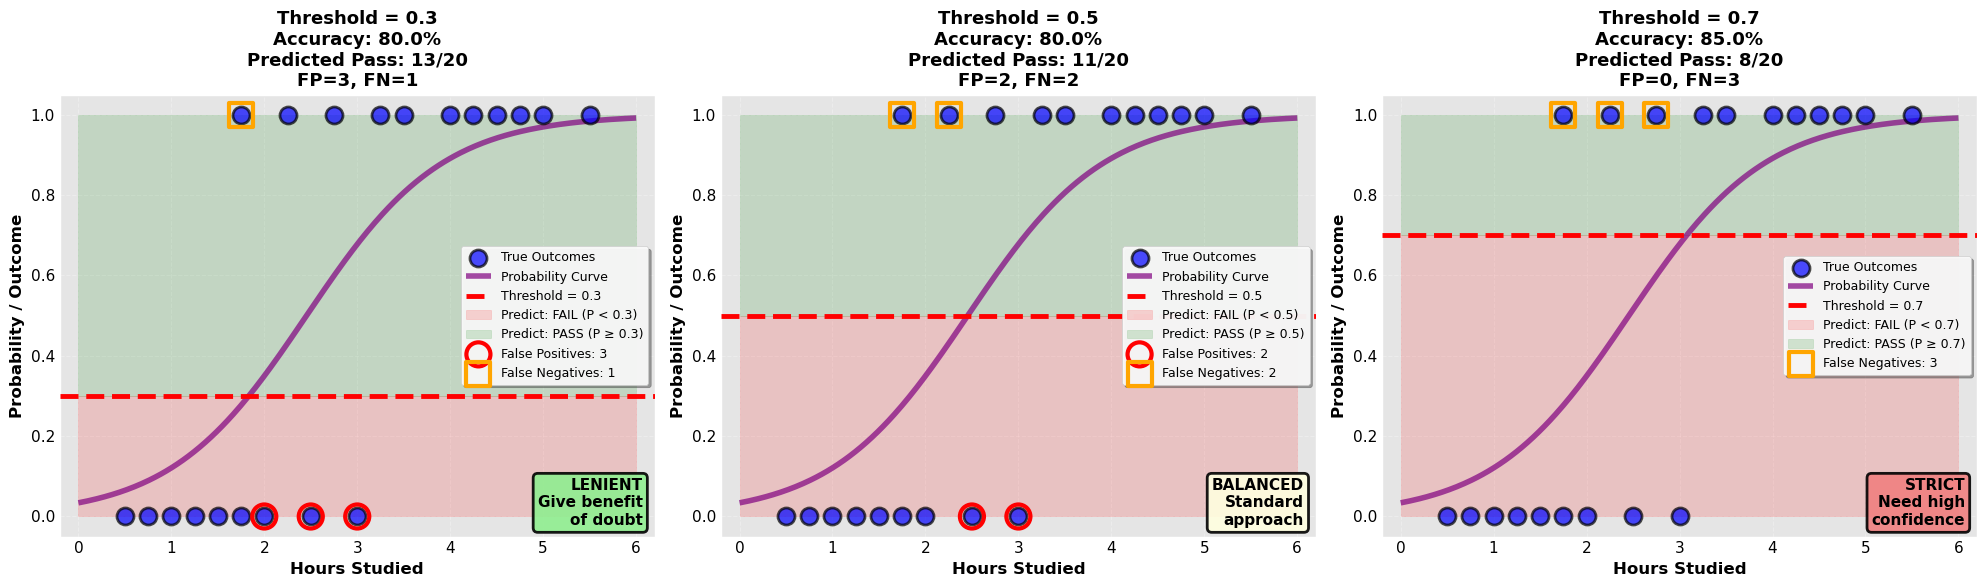


DETAILED THRESHOLD COMPARISON

Threshold    Accuracy     Pred Pass       False Pos    False Neg   
------------------------------------------------------------------------------------------
0.3          80.0%        13/20            3            1           
0.5          80.0%        11/20            2            2           
0.7          85.0%         8/20            0            3           

Actual Pass: 11/20

Best Accuracy: 85.0% at threshold 0.7

KEY INSIGHTS FROM THE EXPERIMENT

1️⃣  THRESHOLD = 0.3 (Lenient):
   Characteristics:
   • More students predicted to pass
   • MORE false positives (predicted pass, actually failed)
   • FEWER false negatives (rarely predict fail when they pass)
   When to use:
   • When missing a true positive is very costly
   • Educational setting: want to give students benefit of doubt
   • Medical screening: don't want to miss sick patients

2️⃣  THRESHOLD = 0.5 (Standard):
   Characteristics:
   • Balanced number of predictions
   • Balanced fals

In [118]:
# Get probability predictions for our training data
# These are the same probabilities the model assigns to each student
train_probs = log_reg.predict_proba(X)[:, 1]

# Test three different thresholds
# 0.3 = lenient (give benefit of doubt)
# 0.5 = standard (sklearn default)
# 0.7 = strict (need to be quite confident)
thresholds = [0.3, 0.5, 0.7]

# Create comprehensive three-panel visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Store results for summary table
results = []

for idx, threshold in enumerate(thresholds):
    ax = axes[idx]

    # Make predictions using this threshold
    # If probability >= threshold, predict 1 (pass), else predict 0 (fail)
    predictions = (train_probs >= threshold).astype(int)

    # Calculate how well these predictions match reality
    accuracy = accuracy_score(y, predictions)

    # Count how many we predicted to pass
    n_predicted_pass = predictions.sum()
    n_actual_pass = y.sum()

    # Count errors
    false_positives = ((predictions == 1) & (y == 0)).sum()
    false_negatives = ((predictions == 0) & (y == 1)).sum()
    true_positives = ((predictions == 1) & (y == 1)).sum()
    true_negatives = ((predictions == 0) & (y == 0)).sum()

    # Store for summary
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'n_pred_pass': n_predicted_pass,
        'false_pos': false_positives,
        'false_neg': false_negatives
    })

    # ========================================================================
    # Create visualization for this threshold
    # ========================================================================

    # Plot the full probability curve
    ax.scatter(hours_studied, passed, color='blue', s=150, alpha=0.7,
              edgecolor='black', linewidth=2, label='True Outcomes', zorder=5)

    ax.plot(X_plot, y_prob_logistic, color='purple', linewidth=4,
           label='Probability Curve', alpha=0.7, zorder=3)

    # Horizontal line at THIS threshold
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=3.5,
              label=f'Threshold = {threshold}', zorder=4)

    # Shade regions based on this threshold
    # Everything above threshold = predict PASS (green)
    # Everything below threshold = predict FAIL (red)
    ax.fill_between(X_plot.ravel(), 0, threshold, alpha=0.15, color='red',
                    label=f'Predict: FAIL (P < {threshold})', zorder=1)
    ax.fill_between(X_plot.ravel(), threshold, 1, alpha=0.15, color='green',
                    label=f'Predict: PASS (P ≥ {threshold})', zorder=1)

    # Highlight incorrect predictions with markers
    # False positives: predicted pass but actually failed
    fp_mask = (predictions == 1) & (y == 0)
    if fp_mask.any():
        ax.scatter(hours_studied[fp_mask], passed[fp_mask],
                  color='none', s=300, edgecolor='red', linewidth=3,
                  marker='o', label=f'False Positives: {false_positives}', zorder=6)

    # False negatives: predicted fail but actually passed
    fn_mask = (predictions == 0) & (y == 1)
    if fn_mask.any():
        ax.scatter(hours_studied[fn_mask], passed[fn_mask],
                  color='none', s=300, edgecolor='orange', linewidth=3,
                  marker='s', label=f'False Negatives: {false_negatives}', zorder=6)

    # Formatting
    ax.set_xlabel('Hours Studied', fontsize=12, fontweight='bold')
    ax.set_ylabel('Probability / Outcome', fontsize=12, fontweight='bold')

    # Create detailed title with all the key metrics
    title = f'Threshold = {threshold}\n'
    title += f'Accuracy: {accuracy:.1%}\n'
    title += f'Predicted Pass: {n_predicted_pass}/{len(y)}\n'
    title += f'FP={false_positives}, FN={false_negatives}'
    ax.set_title(title, fontsize=13, fontweight='bold')

    ax.legend(fontsize=9, loc='center right', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.2, 6.2)

    # Add text box explaining the threshold philosophy
    if threshold == 0.3:
        philosophy = "LENIENT\nGive benefit\nof doubt"
        box_color = 'lightgreen'
    elif threshold == 0.5:
        philosophy = "BALANCED\nStandard\napproach"
        box_color = 'lightyellow'
    else:
        philosophy = "STRICT\nNeed high\nconfidence"
        box_color = 'lightcoral'

    ax.text(0.98, 0.02, philosophy,
           transform=ax.transAxes,
           fontsize=11, fontweight='bold',
           verticalalignment='bottom', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor=box_color,
                    edgecolor='black', linewidth=2, alpha=0.9))

plt.tight_layout()
plt.show()

# ============================================================================
# Print detailed comparison table
# ============================================================================

print("\n" + "="*90)
print("DETAILED THRESHOLD COMPARISON")
print("="*90)

print(f"\n{'Threshold':<12} {'Accuracy':<12} {'Pred Pass':<15} {'False Pos':<12} {'False Neg':<12}")
print("-"*90)

for result in results:
    print(f"{result['threshold']:<12.1f} "
          f"{result['accuracy']:<12.1%} "
          f"{result['n_pred_pass']:>2}/{len(y):<13} "
          f"{result['false_pos']:<12} "
          f"{result['false_neg']:<12}")

print(f"\nActual Pass: {y.sum()}/{len(y)}")

# Analyze which threshold gave best accuracy
best_threshold = max(results, key=lambda x: x['accuracy'])
print(f"\nBest Accuracy: {best_threshold['accuracy']:.1%} at threshold {best_threshold['threshold']}")

print("\n" + "="*90)
print("KEY INSIGHTS FROM THE EXPERIMENT")
print("="*90)

print("\n1️⃣  THRESHOLD = 0.3 (Lenient):")
print("   Characteristics:")
print("   • More students predicted to pass")
print("   • MORE false positives (predicted pass, actually failed)")
print("   • FEWER false negatives (rarely predict fail when they pass)")
print("   When to use:")
print("   • When missing a true positive is very costly")
print("   • Educational setting: want to give students benefit of doubt")
print("   • Medical screening: don't want to miss sick patients")

print("\n2️⃣  THRESHOLD = 0.5 (Standard):")
print("   Characteristics:")
print("   • Balanced number of predictions")
print("   • Balanced false positives and false negatives")
print("   • Often (but not always) gives best accuracy")
print("   When to use:")
print("   • When costs of errors are roughly equal")
print("   • Default choice when you don't have strong reason to adjust")
print("   • Good starting point for analysis")

print("\n3️⃣  THRESHOLD = 0.7 (Strict):")
print("   Characteristics:")
print("   • Fewer students predicted to pass")
print("   • FEWER false positives (rarely predict pass when they fail)")
print("   • MORE false negatives (miss some who actually pass)")
print("   When to use:")
print("   • When false positives are very costly")
print("   • Spam detection: don't want to block real emails")
print("   • Loan approval: don't want to approve risky borrowers")

print("\n" + "="*90)
print("THE FUNDAMENTAL TRADE-OFF")
print("="*90)
print("")
print("Lower Threshold → More Positive Predictions → More False Positives, Fewer False Negatives")
print("Higher Threshold → Fewer Positive Predictions → Fewer False Positives, More False Negatives")
print("")
print("You CANNOT minimize both types of errors simultaneously!")
print("The threshold lets you choose which error you're willing to tolerate.")
print("="*90)

#### **Key Insights on Thresholds**

##### **Lower Threshold (0.3)**: 
* More students predicted to pass
* MORE false positives (predicted pass, actually failed)
* FEWER false negatives (rarely predict fail when they pass)
* When to use:
    * When missing a true positive is very costly
    * Educational setting: want to give students benefit of doubt
    * Medical screening: don't want to miss sick patients

##### **Default Threshold (0.5)**:
* Balanced number of predictions
* Balanced false positives and false negatives
* Often (but not always) gives best accuracy (such as this example)
* When to use:
    * When costs of errors are roughly equal
    * Default choice when you don't have strong reason to adjust
    * Good starting point for analysis

##### **Higher Threshold (0.7)**:
* Fewer students predicted to pass
* FEWER false positives (rarely predict pass when they fail)
* MORE false negatives (miss some who actually pass)
* When to use:
    * When false positives are very costly
    * Spam detection: don't want to block real emails
    * Load approval: don't want to approve risky borrowers

#### **The Fundamental Trade-off**
* Lower Threshold $\longrightarrow$ More Positive Predictions $\longrightarrow$ More False Positives, False Negatives
* Higher Threshold $\longrightarrow$ Fewer Positive Predictions $\longrightarrow$ Fewer False Positives, More False Negatives

**You CANNOT minimize both types of errors simultaneously!**

The threshold lets you choose which error you're willing to tolerate.

We'll explore this more deeply next week when we discuss precision, recall, and ROC curves!

---

## **1.6 Real-World Example: Customer Churn Prediction**

Let's apply logistic regression to a realistic business problem: predicting whether a customer will leave (churn) based on their usage patterns.

In [6]:
# Create a synthetic customer churn dataset
np.random.seed(123)

n_customers = 200

# Features
months_active = np.random.randint(1, 60, n_customers)
monthly_charges = np.random.uniform(20, 150, n_customers)
support_calls = np.random.randint(0, 10, n_customers)

# Generate churn based on features (with some noise)
# More likely to churn if: short tenure, high charges, many support calls
churn_probability = sigmoid(
    -0.05 * months_active +
    0.02 * monthly_charges +
    0.3 * support_calls - 2
)
churned = (np.random.random(n_customers) < churn_probability).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'months_active': months_active,
    'monthly_charges': monthly_charges,
    'support_calls': support_calls,
    'churned': churned
})

print("Customer Churn Dataset:")
print("="*60)
print(df.head(10))
print(f"\nTotal customers: {len(df)}")
print(f"Churned: {df['churned'].sum()} ({df['churned'].mean():.1%})")
print(f"Retained: {(1-df['churned']).sum()} ({(1-df['churned']).mean():.1%})")

Customer Churn Dataset:
   months_active  monthly_charges  support_calls  churned
0             46       126.330576              7        0
1              3        92.733359              1        1
2             29       108.130308              4        1
3             35       125.186468              7        1
4             39       132.914380              4        1
5             18        74.339019              7        0
6             20        27.661960              8        1
7             43        82.199671              0        0
8             58        87.750726              2        0
9             23        95.482163              7        1

Total customers: 200
Churned: 82 (41.0%)
Retained: 118 (59.0%)


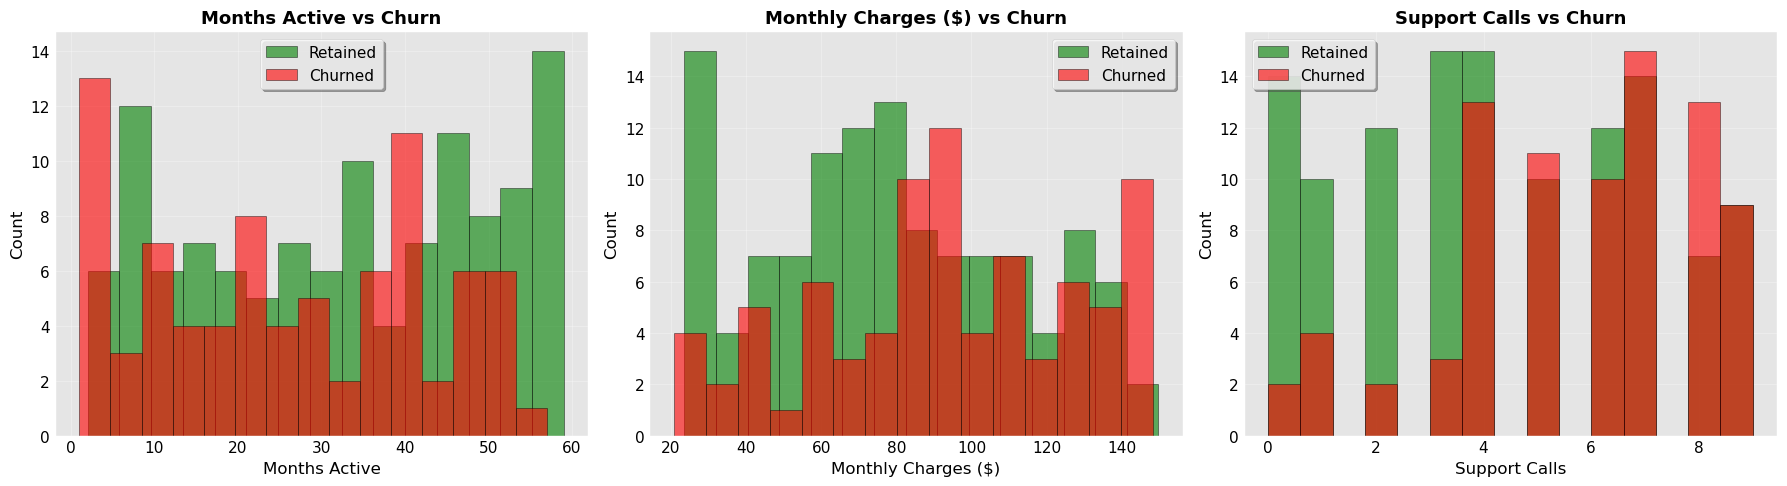

In [7]:
# Visualize the relationship between features and churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['months_active', 'monthly_charges', 'support_calls']
titles = ['Months Active', 'Monthly Charges ($)', 'Support Calls']

for idx, (feature, title) in enumerate(zip(features, titles)):
    ax = axes[idx]

    # Separate churned and retained
    churned_data = df[df['churned'] == 1][feature]
    retained_data = df[df['churned'] == 0][feature]

    ax.hist(retained_data, bins=15, alpha=0.6, color='green', label='Retained', edgecolor='black')
    ax.hist(churned_data, bins=15, alpha=0.6, color='red', label='Churned', edgecolor='black')

    ax.set_xlabel(title, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{title} vs Churn', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Split the data
X = df[['months_active', 'monthly_charges', 'support_calls']]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 140
Test set size: 60


In [9]:
# Train logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Get predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Performance:")
print("="*60)
print(f"Test Accuracy: {accuracy:.1%}")
print(f"\nModel Coefficients:")
print(f"Intercept: {model.intercept_[0]:.4f}")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature:20s}: {coef:8.4f}")


Model Performance:
Test Accuracy: 70.0%

Model Coefficients:
Intercept: -2.6675
months_active       :  -0.0194
monthly_charges     :   0.0167
support_calls       :   0.2606


### **Interpreting Coefficients**

The coefficients tell us how each feature affects the **log-odds** of churn:

- **Negative coefficient**: Decreases probability of churn (protective factor)
- **Positive coefficient**: Increases probability of churn (risk factor)
- **Larger magnitude**: Stronger effect

In our example:
- `months_active` (negative): Longer tenure → less likely to churn ✓
- `monthly_charges` (positive): Higher charges → more likely to churn ✓
- `support_calls` (positive): More problems → more likely to churn ✓

Let's examine some specific predictions:

In [11]:
# Look at some predictions in detail
sample_indices = [0, 15, 30, 45]

print("\nDetailed Predictions for Sample Customers:")
print("="*80)

for idx in sample_indices:
    customer = X_test.iloc[idx]
    true_label = y_test.iloc[idx]
    pred_label = y_pred[idx]
    pred_prob = y_pred_proba[idx]

    print(f"\nCustomer {idx + 1}:")
    print(f"  Features: {customer['months_active']} months, ${customer['monthly_charges']:.2f}/mo, "
          f"{customer['support_calls']} support calls")
    print(f"  Churn Probability: {pred_prob:.1%}")
    print(f"  Predicted: {'CHURN' if pred_label == 1 else 'RETAIN'}")
    print(f"  Actual: {'CHURNED' if true_label == 1 else 'RETAINED'}")
    print(f"  Correct: {'Y' if pred_label == true_label else 'N'}")


Detailed Predictions for Sample Customers:

Customer 1:
  Features: 2.0 months, $96.44/mo, 4.0 support calls
  Churn Probability: 48.7%
  Predicted: RETAIN
  Actual: CHURNED
  Correct: N

Customer 16:
  Features: 49.0 months, $122.99/mo, 0.0 support calls
  Churn Probability: 17.4%
  Predicted: RETAIN
  Actual: RETAINED
  Correct: Y

Customer 31:
  Features: 23.0 months, $95.48/mo, 7.0 support calls
  Churn Probability: 57.6%
  Predicted: CHURN
  Actual: CHURNED
  Correct: Y

Customer 46:
  Features: 11.0 months, $93.63/mo, 6.0 support calls
  Churn Probability: 56.2%
  Predicted: CHURN
  Actual: CHURNED
  Correct: Y


---

## **1.7 Understanding Log-Loss: The Loss Function for Classification**

### **1.7.1 Why Not Mean Squared Error?**

**For linear regression**, we used Mean Squared Error (MSE):
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Problem for classification:** MSE doesn't properly penalize probability estimates.

**Example showing the problem:**
- True label: y = 1 (positive class)
- Prediction A: p̂ = 0.49 → Predicts class 0, MSE = (1-0.49)² = 0.26
- Prediction B: p̂ = 0.01 → Predicts class 0, MSE = (1-0.01)² = 0.98

Both predictions are **wrong** (predict 0 when truth is 1), but MSE treats them very differently. We need a loss function that better captures the quality of probability estimates, not just the final class prediction.

### **1.7.2 The Log-Loss Formula**

**For a single prediction:**

$$\text{Loss} = -[y \log(\hat{p}) + (1-y) \log(1-\hat{p})]$$

**Where:**
- $y$ = true label (0 or 1)
- $\hat{p}$ = predicted probability (between 0 and 1)
- $\log$ = natural logarithm (ln)

**For the entire dataset:**

$$\text{Log-Loss} = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i)]$$

### **1.7.3 Understanding the Formula**

The formula has **two parts** depending on the true label:

**If true label is 1** (y=1):
$$\text{Loss} = -\log(\hat{p})$$
- Predicting high probability (e.g., 0.9) → small loss
- Predicting low probability (e.g., 0.1) → large loss
- Predicting very low probability (e.g., 0.01) → HUGE loss

**If true label is 0** (y=0):
$$\text{Loss} = -\log(1-\hat{p})$$
- Predicting low probability (e.g., 0.1) → small loss
- Predicting high probability (e.g., 0.9) → large loss
- Predicting very high probability (e.g., 0.99) → HUGE loss

**Why the formula works this way:**
- When y=1, the second term becomes 0, leaving only $-\log(\hat{p})$
- When y=0, the first term becomes 0, leaving only $-\log(1-\hat{p})$
- The negative sign ensures loss is positive (since log of values <1 is negative)

### **1.7.4 Key Properties**

#### **1.7.4.1 Heavily penalizes confident wrong predictions**

Being confidently wrong is much worse than being uncertain:
- True=1, Predict=0.01: Loss ≈ 4.6 (disaster!)
- True=1, Predict=0.40: Loss ≈ 0.9 (not great but tolerable)

#### **1.7.4.2 Lower is better**
- Perfect prediction (p̂=1 when y=1): Loss = 0
- Worst prediction (p̂=0 when y=1): Loss = ∞
- Encourages model to be as confident as possible when correct

#### **1.7.4.3 Smooth and differentiable**
- No sudden jumps or discontinuities
- Gradient exists everywhere
- Perfect for gradient descent optimization

#### **1.7.4.4 Encourages probability calibration**
- Rewards not just getting the class right, but being appropriately confident
- A 70% prediction should be right about 70% of the time
- Promotes honest uncertainty quantification

### **1.7.5 Visualizing Log-Loss**

Let's see how log-loss changes with different predictions:

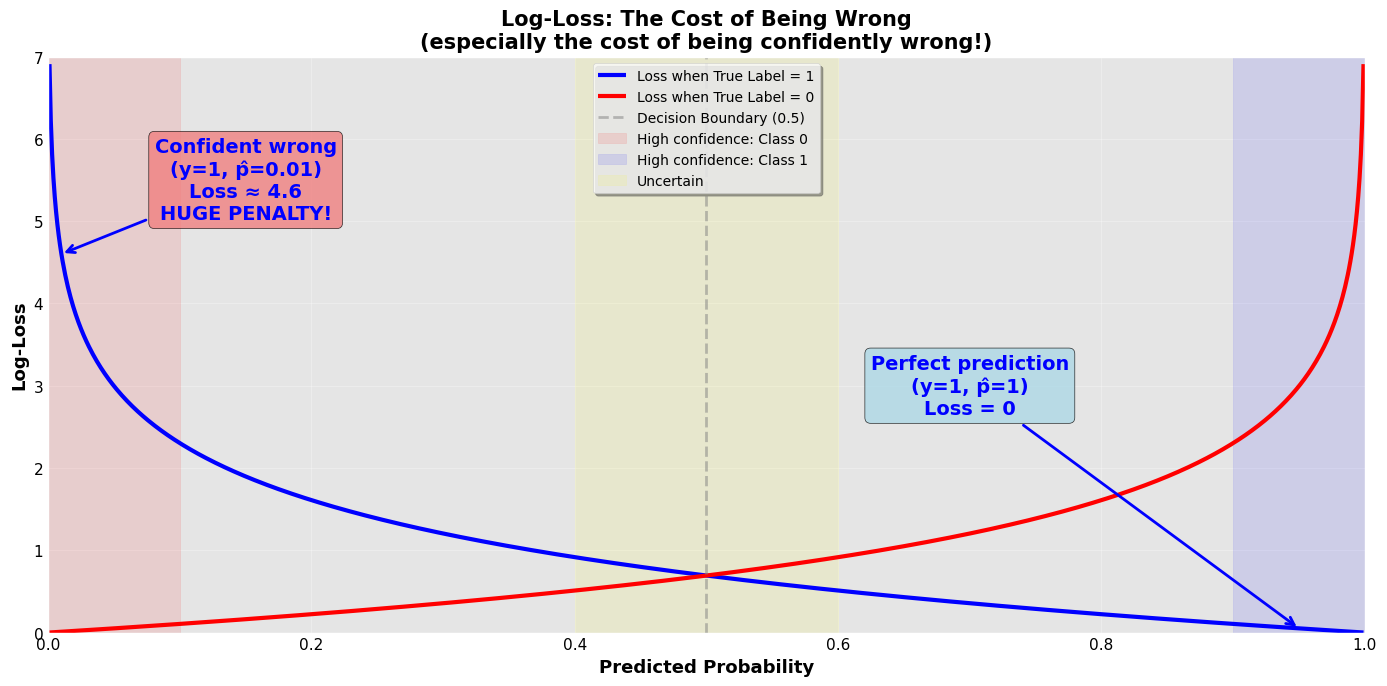

In [123]:
# Visualize log-loss penalties
predicted_probs = np.linspace(0.001, 0.999, 1000)

# Loss when true label is 1
loss_when_true_1 = -np.log(predicted_probs)

# Loss when true label is 0
loss_when_true_0 = -np.log(1 - predicted_probs)

plt.figure(figsize=(14, 7))

# Plot both loss curves
plt.plot(predicted_probs, loss_when_true_1, linewidth=3, color='blue',
        label='Loss when True Label = 1', zorder=2)
plt.plot(predicted_probs, loss_when_true_0, linewidth=3, color='red',
        label='Loss when True Label = 0', zorder=2)

# Add reference lines
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5,
           label='Decision Boundary (0.5)')

# Highlight key regions
plt.axvspan(0, 0.1, alpha=0.1, color='red', label='High confidence: Class 0')
plt.axvspan(0.9, 1, alpha=0.1, color='blue', label='High confidence: Class 1')
plt.axvspan(0.4, 0.6, alpha=0.1, color='yellow', label='Uncertain')

# Add annotations
plt.annotate('Perfect prediction\n(y=1, p̂=1)\nLoss = 0',
            xy=(0.95, 0.05), xytext=(0.7, 3), ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='blue', lw=2),
            fontsize=14, color='blue', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.annotate('Confident wrong\n(y=1, p̂=0.01)\nLoss ≈ 4.6\nHUGE PENALTY!',
            xy=(0.01, 4.6), xytext=(0.15, 5.5), ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='blue', lw=2),
            fontsize=14, color='blue', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

plt.xlabel('Predicted Probability', fontsize=13, fontweight='bold')
plt.ylabel('Log-Loss', fontsize=13, fontweight='bold')
plt.title('Log-Loss: The Cost of Being Wrong\n(especially the cost of being confidently wrong!)',
         fontsize=15, fontweight='bold')
plt.legend(fontsize=10, loc='upper center')
plt.grid(True, alpha=0.3)
plt.ylim(0, 7)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [125]:
# Show concrete examples
print("Log-Loss Examples")
print("=" * 80)
print("\nWhen True Label = 1 (Positive Class):")
print("-" * 80)
print(f"{'Predicted P(y=1)':<20} {'Loss':<15} {'Interpretation'}")
print("-" * 80)

test_probs = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
for prob in test_probs:
    loss = -np.log(prob)
    if prob < 0.3:
        interp = "TERRIBLE - Very confident but wrong"
    elif prob < 0.5:
        interp = "Bad - Leaning wrong way"
    elif prob < 0.7:
        interp = "OK - Leaning right way but uncertain"
    elif prob < 0.9:
        interp = "Good - Fairly confident and correct"
    else:
        interp = "EXCELLENT - Very confident and correct"

    print(f"{prob:<20.2f} {loss:<15.4f} {interp}")

print("\nWhen True Label = 0 (Negative Class):")
print("-" * 80)
print(f"{'Predicted P(y=1)':<20} {'Loss':<15} {'Interpretation'}")
print("-" * 80)

for prob in test_probs:
    loss = -np.log(1 - prob)
    if prob > 0.7:
        interp = "TERRIBLE - Very confident but wrong"
    elif prob > 0.5:
        interp = "Bad - Leaning wrong way"
    elif prob > 0.3:
        interp = "OK - Leaning right way but uncertain"
    elif prob > 0.1:
        interp = "Good - Fairly confident and correct"
    else:
        interp = "EXCELLENT - Very confident and correct"

    print(f"{prob:<20.2f} {loss:<15.4f} {interp}")

Log-Loss Examples

When True Label = 1 (Positive Class):
--------------------------------------------------------------------------------
Predicted P(y=1)     Loss            Interpretation
--------------------------------------------------------------------------------
0.01                 4.6052          TERRIBLE - Very confident but wrong
0.10                 2.3026          TERRIBLE - Very confident but wrong
0.30                 1.2040          Bad - Leaning wrong way
0.50                 0.6931          OK - Leaning right way but uncertain
0.70                 0.3567          Good - Fairly confident and correct
0.90                 0.1054          EXCELLENT - Very confident and correct
0.99                 0.0101          EXCELLENT - Very confident and correct

When True Label = 0 (Negative Class):
--------------------------------------------------------------------------------
Predicted P(y=1)     Loss            Interpretation
---------------------------------------------------

#### **Key Insight**
Log-loss heavily penalized confident wrong predictions!  
This encourages the model to:
* Be honest about uncertainty
* Only be confident when evidence is strong
* Produce well-calibrated probabilities

### **1.7.6 Comparing Predictions**

#### **1.7.6.1 Scenario 1: True label = 1 (Patient IS sick)**

| Prediction | Binary Outcome | MSE | Log-Loss | Interpretation |
|------------|---------------|-----|----------|----------------|
| 0.51 | Correct (≥0.5) | 0.24 | 0.67 | Barely right, low confidence |
| 0.90 | Correct (≥0.5) | 0.01 | 0.11 | Correct AND confident ✓ |
| 0.49 | Wrong (<0.5) | 0.26 | 0.71 | Barely wrong |
| 0.01 | Wrong (<0.5) | 0.98 | 4.61 | Very wrong AND confident ✗✗✗ |

#### **1.7.6.2 Scenario 2: True label = 0 (Patient is NOT sick)**

| Prediction | Binary Outcome | MSE | Log-Loss | Interpretation |
|------------|---------------|-----|----------|----------------|
| 0.49 | Correct (<0.5) | 0.24 | 0.67 | Barely right, low confidence |
| 0.10 | Correct (<0.5) | 0.01 | 0.11 | Correct AND confident ✓ |
| 0.51 | Wrong (≥0.5) | 0.26 | 0.71 | Barely wrong |
| 0.99 | Wrong (≥0.5) | 0.98 | 4.61 | Very wrong AND confident ✗✗✗ |

#### **1.7.6.3 Key observations:**

##### **From MSE column:**
- MSE treats symmetric errors the same: predicting 0.51 when truth=1 has same MSE (0.24) as predicting 0.49 when truth=1
- MSE cares about distance, not direction or confidence
- MSE doesn't distinguish between "barely wrong" and "confidently wrong" predictions of the same distance

##### **From Log-Loss column:**
- Log-loss is **symmetric**: Same loss for predicting 0.01 when truth=1 as predicting 0.99 when truth=0 (both ≈4.61)
- Being confidently wrong receives massive penalty regardless of which class
- Being barely right (0.51 when truth=1, or 0.49 when truth=0) gets moderate penalty for low confidence
- Being right AND confident (0.90 when truth=1, or 0.10 when truth=0) gets low loss ✓

##### **The crucial difference:**
- **MSE** rewards predictions close to the true value (treats it as regression)
- **Log-loss** rewards confident correct predictions AND penalizes confident wrong predictions
- Log-loss cares about the **quality of probability estimates**, not just binary correctness

#### **1.7.6.4 Real Example: Medical Diagnosis**

Imagine diagnosing 100 patients for a disease:

##### **Doctor A (Over-confident):**
- Predicts 0.99 for sick patients ✓
- Predicts 0.99 for healthy patients ✗ (disaster!)
- Gets some very right, some catastrophically wrong
- High log-loss due to confident errors

##### **Doctor B (Under-confident):**
- Predicts 0.55 for sick patients (barely right)
- Predicts 0.45 for healthy patients (barely right)
- Always technically correct but never confident
- Moderate log-loss, but not very useful

##### **Doctor C (Well-calibrated):**
- Predicts 0.85 for sick patients ✓
- Predicts 0.15 for healthy patients ✓
- Confident when evidence is strong, uncertain when not
- Low log-loss AND provides useful information

**Log-loss rewards Doctor C** for being both accurate and appropriately confident!

#### **1.7.6.5 Why This Matters**

**Log-loss encourages good behavior:**

1. **Well-calibrated probabilities**: If the model says 70%, it should be right ~70% of the time
2. **Honest uncertainty**: When uncertain, predict probabilities near 0.5
3. **Confidence when justified**: Only predict extreme probabilities (near 0 or 1) when evidence is very strong
4. **Epistemological humility**: Never claim 100% certainty (which would require infinite negative evidence)

**This is built-in wisdom!** The loss function mathematically encodes the principle: "Being wrong is bad, but being confidently wrong is much worse."

### **1.7.7 Practical Implications**

When training logistic regression:
- The model minimizes log-loss across all training examples
- It learns coefficients (β₀, β₁, ...) that produce well-calibrated probabilities
- Gradient descent uses the derivative of log-loss to update parameters
- The resulting probabilities can be trusted (not just the final classifications)

**Next week** we'll learn about metrics (precision, recall, ROC-AUC) that help us evaluate these probabilities in different contexts!

---

## **1.8 Scikit-Learn Implementation: Complete Workflow**

Let's review the complete workflow for logistic regression:

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Create a pipeline (standardization + logistic regression)
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Cross-validation score
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)

print("\nComplete Pipeline Results:")
print("="*60)
print(f"Training Accuracy: {pipeline.score(X_train, y_train):.1%}")
print(f"Test Accuracy: {pipeline.score(X_test, y_test):.1%}")
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.1%} (+/- {cv_scores.std():.1%})")


Complete Pipeline Results:
Training Accuracy: 67.9%
Test Accuracy: 70.0%
Cross-Validation Scores: [0.60714286 0.53571429 0.78571429 0.67857143 0.75      ]
Mean CV Accuracy: 67.1% (+/- 9.1%)


In [14]:
# Important methods for LogisticRegression
print("\nKey Methods in Logistic Regression:")
print("="*60)
print("\n1. fit(X, y)")
print("   - Trains the model on data")

print("\n2. predict(X)")
print("   - Returns class predictions (0 or 1)")
print(f"   - Example: {pipeline.predict(X_test[:3])}")

print("\n3. predict_proba(X)")
print("   - Returns probability estimates [P(class=0), P(class=1)]")
print(f"   - Example: {pipeline.predict_proba(X_test[:3])}")

print("\n4. score(X, y)")
print("   - Returns accuracy score")
print(f"   - Example: {pipeline.score(X_test, y_test):.4f}")

print("\n5. decision_function(X)")
print("   - Returns raw decision values (before sigmoid)")
print(f"   - Example: {pipeline.decision_function(X_test[:3])}")


Key Methods in Logistic Regression:

1. fit(X, y)
   - Trains the model on data

2. predict(X)
   - Returns class predictions (0 or 1)
   - Example: [0 0 0]

3. predict_proba(X)
   - Returns probability estimates [P(class=0), P(class=1)]
   - Example: [[0.52062711 0.47937289]
 [0.87282681 0.12717319]
 [0.63618626 0.36381374]]

4. score(X, y)
   - Returns accuracy score
   - Example: 0.7000

5. decision_function(X)
   - Returns raw decision values (before sigmoid)
   - Example: [-0.08255528 -1.92618732 -0.55884933]


---

## **BREAK (10-15 minutes)**

---

## **2.1 Lab Exercises** (new notebook)

---

## **3.1: Review & Wrap-Up**

### **3.1.1 Key Takeaways**

Let's summarize what we've learned today:

1. **Classification vs Regression**
   - Classification predicts categories (discrete)
   - Regression predicts continuous values
   - Linear regression fails for classification (outputs outside [0,1])

2. **The Sigmoid Function**
   - Formula: $\sigma(z) = \frac{1}{1 + e^{-z}}$
   - Maps any real number to [0, 1]
   - S-shaped curve with midpoint at 0.5
   - Perfect for modeling probabilities

3. **Logistic Regression Model**
   - Combines linear model with sigmoid function
   - Outputs probabilities, not just classes
   - Uses log-loss instead of MSE
   - Interpretable coefficients (feature importance)

4. **Decision Thresholds**
   - Default threshold = 0.5
   - Can be adjusted based on business needs
   - Lower threshold: More sensitive (catch more positives)
   - Higher threshold: More specific (fewer false positives)

5. **Log-Loss**
   - Penalizes confident wrong predictions heavily
   - Encourages well-calibrated probabilities
   - Smooth and differentiable (good for optimization)

### **3.1.2 Practical Skills**

- Implementing logistic regression with scikit-learn
- Interpreting coefficients and probabilities
- Using `.predict()` vs `.predict_proba()`
- Building pipelines with standardization
- Adjusting decision thresholds

### **3.1.3 Important Questions to Ask**

1. Is this a classification or regression problem?
2. Are my features on similar scales? (If not, standardize!)
3. What threshold should I use for my specific application?
4. How confident should my model be in its predictions?
5. What's more important: catching all positives or avoiding false positives?


---

## **3.2 Coming Up**

### **3.2.1 Coming Up in Week 7**

1. **Beyond Accuracy**
   - Why accuracy can be misleading
   - The class imbalance problem

2. **Confusion Matrix**
   - True Positives, False Positives, True Negatives, False Negatives
   - Visualizing classification performance

3. **Precision and Recall**
   - Precision: Of predicted positives, how many are correct?
   - Recall: Of actual positives, how many did we catch?
   - F1-Score: Harmonic mean of precision and recall

4. **ROC Curves and AUC**
   - Receiver Operating Characteristic curves
   - Area Under the Curve (AUC)
   - Comparing models visually

5. **Choosing the Right Metric**
   - Medical diagnosis vs spam detection
   - Business context matters!
   - Imbalanced datasets

### **3.2.2 Why This Matters**

Understanding evaluation metrics is **critical** for:
- Selecting the best model for your problem
- Tuning decision thresholds appropriately
- Communicating results to stakeholders
- Avoiding misleading conclusions

**Prepare by**: 
- Completing this week's lab on logistic regression
- Practicing with `.predict_proba()` to understand probabilities
- Thinking about different classification scenarios (medical, finance, etc.)

### **3.2.3 Homework Reminder**
- **Lab due:** Monday, 09 March @ 6:00 PM (grace period: Wednesday, 11 March @ 11:59 PM)